# Spaceship Titanic — Preprocesamiento de datos

**Materia:** Inteligencia Artificial Avanzada
**Equipo:** _(6)_
**Integrantes:** _(Juan Pablo Pérez Gutiérrez A01800483, Erik Owen Castro Flores A01800371, Yael Michel García López A01750911, Alean Reynoso Rangel A01800849, Alberto Gallegos Hernández A01752303)_
**Fecha:** _(31/08/2026)_

---

Este notebook cubre el pipeline de preparación de datos del reto
[Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic):
carga, EDA, selección de variables, manejo de faltantes, codificación,
transformación, escalado y verificación final.

Las celdas marcadas como **Interpretación** contienen el razonamiento del equipo
detrás de cada decisión; las celdas de código sólo generan la evidencia.

## 0. Configuración del entorno

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")  # oculta warnings para no ensuciar la salida

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)  # semilla fija para reproducibilidad

# Opciones de despliegue de pandas/matplotlib/seaborn
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 4)

# Los CSV viven en <repo>/data/spaceship-titanic/.
# Buscamos en varias rutas para que funcione tanto si ejecutas el notebook
# desde SpaceShip_Titanic/ como desde la raiz del repositorio.
CANDIDATAS = [
    Path("../data/spaceship-titanic"),
    Path("data/spaceship-titanic"),
    Path("data"),
]
DATA_DIR = next(
    (c for c in CANDIDATAS if (c / "train.csv").exists()),
    CANDIDATAS[0],
)  # primera ruta candidata que exista; si ninguna existe, usa la primera como default
print("DATA_DIR:", DATA_DIR.resolve())

print("pandas", pd.__version__, "| numpy", np.__version__)  # versiones para reproducibilidad

DATA_DIR: C:\Users\juand\OneDrive\Documents\GitHub\Reto---Entregas-en-Equipo\data\spaceship-titanic
pandas 3.0.5 | numpy 2.5.2


## 1. Carga y comprensión del dataset

In [2]:
# Carga de los conjuntos de entrenamiento y prueba provistos por Kaggle
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print("train:", train.shape, "| test:", test.shape)

train: (8693, 14) | test: (4277, 13)


In [3]:
train.head()  # primeras filas para inspeccion visual rapida

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
train.info()  # tipos de dato y conteo de no-nulos por columna

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [5]:
# Confirma tamanios y que la unica diferencia de columnas entre train y test sea el target
print("train shape:", train.shape)
print("test shape:", test.shape)

cols_train = set(train.columns)
cols_test = set(test.columns)
print("Columnas en train pero no en test:", cols_train - cols_test)
print("Columnas en test pero no en train:", cols_test - cols_train)

train shape: (8693, 14)
test shape: (4277, 13)
Columnas en train pero no en test: {'Transported'}
Columnas en test pero no en train: set()


In [6]:
train.describe()  # estadisticos descriptivos de las columnas numericas

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [7]:
train.describe(include="object")  # conteo, cardinalidad y valor mas frecuente de las columnas categoricas

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
count,8693,8492,8476,8494,8511,8490,8493
unique,8693,3,2,6560,3,2,8473
top,0001_01,Earth,False,G/734/S,TRAPPIST-1e,False,Elaney Webstephrey
freq,1,4602,5439,8,5915,8291,2


In [8]:
train["Transported"].value_counts(normalize=True)  # proporcion de cada clase del target

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64

### Interpretación — variable target y tipo de problema

La variable target del dataset es `Transported`, de tipo booleano (`True`/`False`), que indica si el pasajero fue transportado a otra dimensión durante el accidente. Al tratarse de una variable con únicamente dos valores posibles, el problema es de **clasificación binaria**.

Al revisar la distribución de clases con `value_counts(normalize=True)` se obtiene un balance de 50.4% para `True` y 49.6% para `False`. Las clases están prácticamente balanceadas, por lo que no se requiere ningún tratamiento especial de desbalance (como *class weights* o técnicas de *resampling*) más adelante en el pipeline.

Por su parte, `test.csv` cuenta con una columna menos que `train.csv`: justamente `Transported`. Esto se debe a que `test.csv` es el conjunto sobre el que se generarán las predicciones nuevas del modelo, simulando la situación real en la que el resultado todavía no se conoce. Kaggle oculta esa columna en su propio servidor para poder evaluar las predicciones del equipo contra los valores reales una vez enviadas.

## 2. Análisis exploratorio (EDA)

### 2.1 Faltantes: informativos vs. reales

In [9]:
# Porcentaje de valores faltantes por columna, solo las que tienen al menos un faltante
faltantes_pct = train.isna().mean().sort_values(ascending=False) * 100
faltantes_pct = faltantes_pct[faltantes_pct > 0]
faltantes_pct

CryoSleep       2.496261
ShoppingMall    2.392730
VIP             2.335212
HomePlanet      2.312205
Name            2.300702
Cabin           2.289198
VRDeck          2.162660
Spa             2.105142
FoodCourt       2.105142
Destination     2.093639
RoomService     2.082135
Age             2.059128
dtype: float64

In [10]:
# Estadisticos de gasto para pasajeros con CryoSleep=True: si la logica del dominio se cumple, deberia ser todo 0
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
train.loc[train["CryoSleep"] == True, spend_cols].describe()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,2969.0,2967.0,2941.0,2972.0,2975.0
mean,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0


In [11]:
# Estadisticos de gasto para pasajeros con CryoSleep=False: aqui si esperamos ver gasto real y su dispersion
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
train.loc[train["CryoSleep"] == False, spend_cols].describe()

,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,5328.000000,5329.000000,5335.000000,5326.000000,5320.000000
mean,350.146772,713.004316,270.586504,486.092940,475.716165
std,803.080320,1970.547985,741.756155,1396.233751,1404.174304
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,5.000000,2.000000,7.000000,4.000000
75%,390.250000,537.000000,242.000000,354.750000,356.000000
max,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [12]:
# Gasto total (suma de las 5 columnas) agrupado por CryoSleep, para comparar el patron entre True y False
train.assign(TotalSpend=train[spend_cols].sum(axis=1)).groupby("CryoSleep")["TotalSpend"].describe()

,count,mean,std,min,25%,50%,75%,max
CryoSleep,,,,,,,,
False,5439.0,2248.299687,3245.061489,0.0,746.0,1019.0,2416.0,35987.0
True,3037.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [13]:
# PassengerId tiene formato gggg_pp (grupo_persona); extraemos el grupo de viaje
train["Group"] = train["PassengerId"].str.split("_").str[0]

# Cuantas personas viajan juntas en el mismo grupo (tamano de cada grupo)
train.groupby("Group").size().value_counts().sort_index()

1    4805
2     841
3     340
4     103
5      53
6      29
7      33
8      13
Name: count, dtype: int64

In [14]:
# Por grupo, cuantos valores distintos de HomePlanet hay (sin contar nulos)
# Si el resultado es casi siempre 1, el grupo comparte planeta de origen
homeplanet_por_grupo = train.groupby("Group")["HomePlanet"].nunique(dropna=True)
homeplanet_por_grupo.value_counts().sort_index()

HomePlanet
0     110
1    6107
Name: count, dtype: int64

In [15]:
# Extraemos el Deck (primera parte de Cabin, formato deck/num/side)
train["Deck"] = train["Cabin"].str.split("/").str[0]

# Por grupo, cuantos Decks distintos hay (sin contar nulos)
deck_por_grupo = train.groupby("Group")["Deck"].nunique(dropna=True)
deck_por_grupo.value_counts().sort_index()

Deck
0      99
1    5697
2     400
3      21
Name: count, dtype: int64

#### Interpretación — clasificación de faltantes

**Uniformidad del porcentaje de faltantes.** Las 12 columnas con nulos van de 2.06% (`Age`) a 2.50% (`CryoSleep`), un rango de apenas 0.44 puntos porcentuales, ninguna se dispara por encima del resto. Esa uniformidad es la primera señal de que los faltantes fueron inyectados de forma aleatoria e independiente en cada columna, y no por un mecanismo que afecte desproporcionadamente a una sola variable.

Al separar el gasto por valor de `CryoSleep`, los cinco rubros (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`) tienen media, desviación estándar, mínimo y máximo de **exactamente 0** para los pasajeros dormidos con dato no nulo; para los despiertos, el gasto es claramente positivo (medias entre 270 y 713, colas hasta ~30,000). El gasto total agrupado por `CryoSleep` confirma lo mismo: media 0.0 y desviación 0.0 para `True`, media 2,248 para `False`. La conclusión es que un pasajero en criosueño no puede generar gasto, no es una correlación estadística, es una restricción del escenario. Por lo tanto, un gasto faltante en un pasajero con `CryoSleep=True` no es un valor desconocido: es un cero no registrado, y se puede imputar como tal sin recurrir a estadísticos. Este es el prototipo de **faltante informativo**.

- **HomePlanet.** El análisis por grupo de viaje (`Group`, extraído de `PassengerId`) muestra que, de los grupos con al menos un valor conocido, ninguno mezcla dos planetas distintos: todos los integrantes de un mismo grupo comparten `HomePlanet`. Es un faltante real (no lo explica ninguna otra variable observada), pero recuperable con alta confianza mediante la estructura de grupo, en vez de recurrir directamente a la moda global.
- **Cabin (Deck).** El mismo análisis por grupo aplicado a `Deck` muestra que ~93% de los grupos con dato conocido comparten un único deck; el otro ~7% mezcla dos o tres decks distintos. Es real, también recuperable por grupo (moda), aunque con algo menos de certeza que `HomePlanet`.
- **Destination.** No se observa relación con el grupo de viaje, el planeta de origen ni el gasto; su 2.09% de faltantes se ve puramente aleatorio, sin ninguna variable que permita deducirlo. Es un faltante real sin patrón aprovechable.
- **VIP.** Igual que `Destination`, no hay ninguna otra columna que explique su ausencia (2.34% de faltantes, sin relación aparente). Real y aleatorio.
- **Name.** Es un identificador de texto libre, casi único por fila; su ausencia no se relaciona con ninguna otra variable, y dado que tampoco aporta señal predictiva directa, no amerita ni siquiera un esfuerzo de imputación fino.
- **Age.** No muestra relación con `CryoSleep`, `HomePlanet` ni ninguna otra columna disponible; 2.06% de faltantes repartidos sin patrón visible. Real, se resuelve con imputación estadística.


### 2.2 Variables numéricas: distribución, skewness y outliers

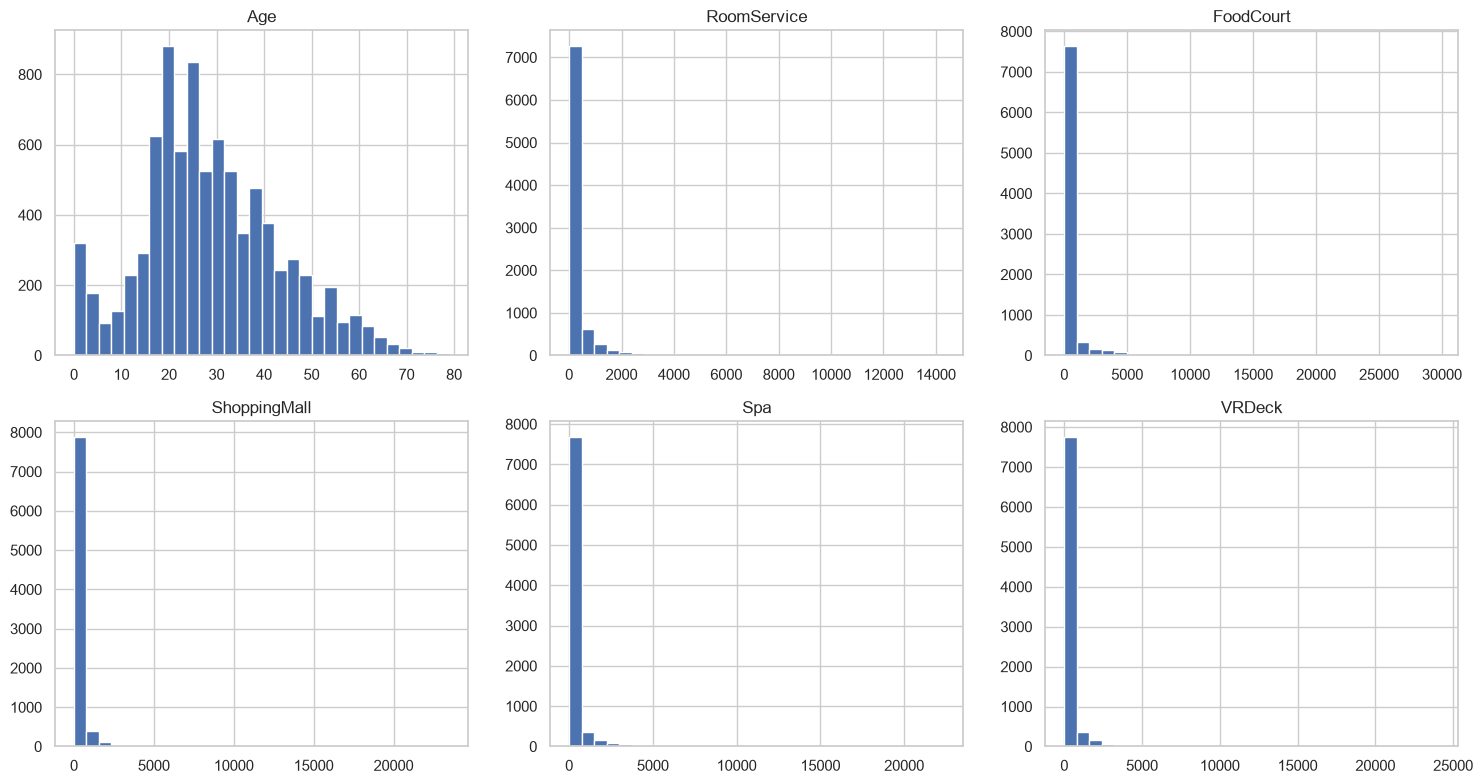

In [16]:
# Columnas numericas continuas del dataset (Transported es el target booleano, no entra aqui)
numeric_cols = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(numeric_cols, axes.flatten()):
    train[col].hist(bins=30, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [17]:
# Skewness (asimetria) de cada variable numerica: cerca de 0 = simetrica, >1 o <-1 = sesgo fuerte
train[numeric_cols].skew().sort_values(ascending=False)

ShoppingMall    12.627562
VRDeck           7.819732
Spa              7.636020
FoodCourt        7.102228
RoomService      6.333014
Age              0.419097
dtype: float64

In [18]:
# Deteccion de outliers con la regla de Tukey / IQR: fuera de [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
def resumen_outliers_iqr(df, cols):
    filas = []
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lim_inf = q1 - 1.5 * iqr
        lim_sup = q3 + 1.5 * iqr
        n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
        filas.append({
            "columna": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "limite_inferior": lim_inf,
            "limite_superior": lim_sup,
            "n_outliers": n_outliers,
            "pct_outliers": 100 * n_outliers / df[col].notna().sum(),
        })
    return pd.DataFrame(filas)


resumen_outliers_iqr(train, numeric_cols)

,columna,Q1,Q3,IQR,limite_inferior,limite_superior,n_outliers,pct_outliers
0,Age,19.0,38.0,19.0,-9.5,66.5,77,0.904393
1,RoomService,0.0,47.0,47.0,-70.5,117.5,1861,21.863252
2,FoodCourt,0.0,76.0,76.0,-114.0,190.0,1823,21.421857
3,ShoppingMall,0.0,27.0,27.0,-40.5,67.5,1829,21.555687
4,Spa,0.0,59.0,59.0,-88.5,147.5,1788,21.010576
5,VRDeck,0.0,46.0,46.0,-69.0,115.0,1809,21.269841


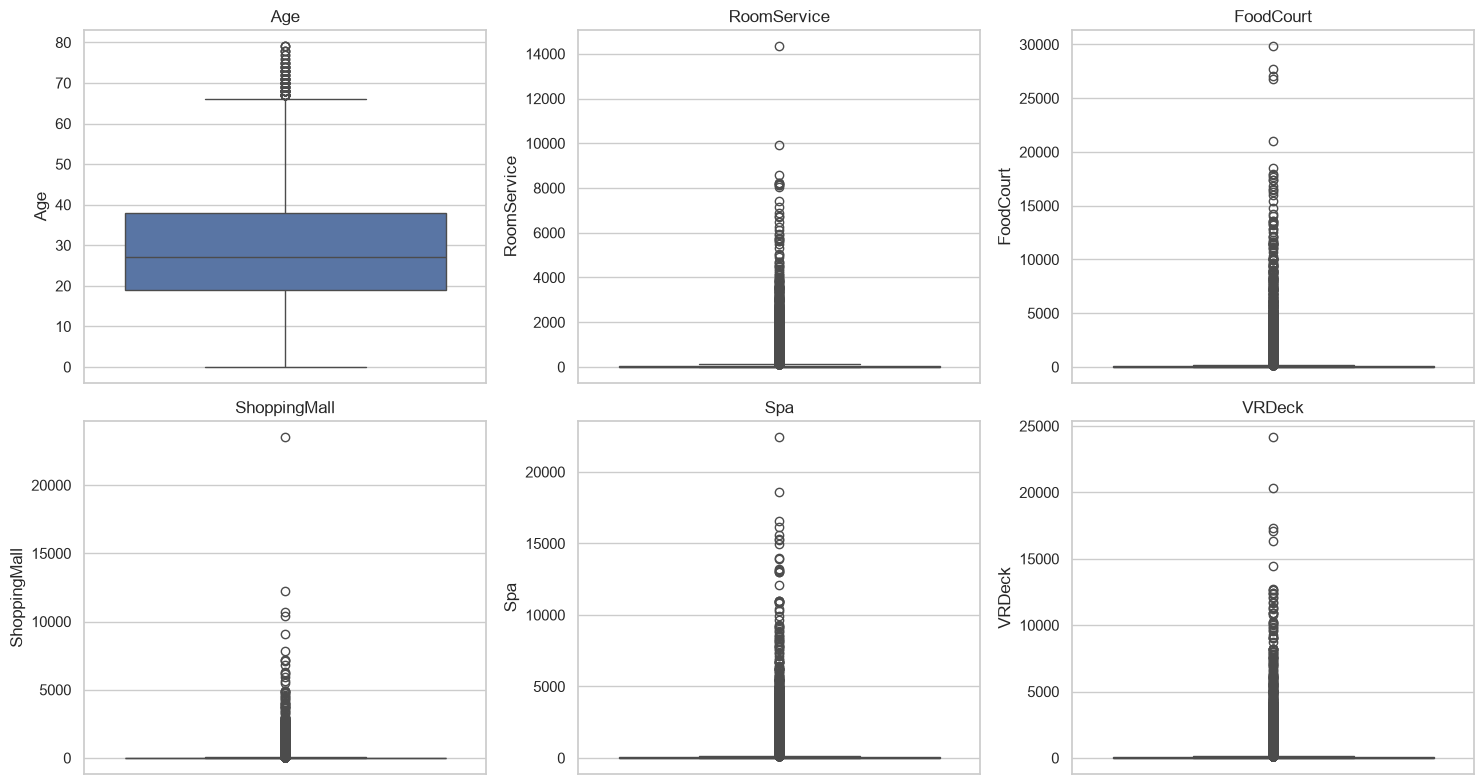

In [19]:
# Boxplots para visualizar dispersion y outliers de cada variable numerica
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.boxplot(y=train[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

#### Interpretación — distribución, skewness y outliers

**Sesgo.** Las 5 columnas de gasto tienen sesgo fuertemente positivo, de 6.33 (`RoomService`) a 12.63 (`ShoppingMall`), colas larguísimas hacia la derecha causadas por un grupo pequeño de pasajeros con gasto muy alto (hasta ~30,000). `Age` es la única prácticamente simétrica (sesgo 0.42).

**Outliers (regla de Tukey/IQR).** `Age` tiene apenas 0.90% de outliers. Las 5 columnas de gasto, en cambio, rondan todas el **21%** (21.86% `RoomService`, 21.42% `FoodCourt`, 21.56% `ShoppingMall`, 21.01% `Spa`, 21.27% `VRDeck`) , un porcentaje enorme y notablemente uniforme entre sí.

**¿Son errores o datos legítimos?** No son errores. En las 5 columnas de gasto, `Q1 = 0` y `Q3` es pequeño (27 a 76), porque la mayoría de los pasajeros gastó exactamente 0 (mediana 0). Con un IQR tan chico, el límite superior de Tukey queda muy bajo (p. ej. 117.5 para `RoomService`), así que cualquier pasajero que sí gastó una cantidad moderada o alta queda marcado como "outlier", aunque sea una transacción perfectamente real. El problema no es que haya errores de captura: es que la regla de IQR asume una distribución razonablemente simétrica, y aquí el exceso de ceros (zero-inflation) la rompe. Eliminar estos "outliers" borraría precisamente a los pasajeros que sí consumieron servicios, información legítima y, según la sección 2.4, con relación directa con el target, así que no se eliminan.

**Transformación anticipada.** Dado el sesgo tan fuerte, todo positivo y con una gran masa de ceros (donde `log(0)` no está definido), la transformación natural para la sección 6 es `log1p` sobre las 5 columnas de gasto, y no sobre `Age`, que ya está razonablemente simétrica.


### 2.3 Variables categóricas: cardinalidad y desbalance

In [20]:
# Cardinalidad (numero de valores unicos) de cada columna categorica, incluyendo Deck y Group derivadas
cat_cols_all = ["HomePlanet", "CryoSleep", "Cabin", "Destination", "VIP", "Name", "Deck", "Group"]
train[cat_cols_all].nunique().sort_values(ascending=False)

Name           8473
Cabin          6560
Group          6217
Deck              8
HomePlanet        3
Destination       3
CryoSleep         2
VIP               2
dtype: int64

In [21]:
# Distribucion de categorias (proporcion) para las columnas de baja cardinalidad
cat_cols_baja_card = ["HomePlanet", "CryoSleep", "Destination", "VIP", "Deck"]
for col in cat_cols_baja_card:
    print(f"--- {col} ---")
    print(train[col].value_counts(normalize=True, dropna=False))
    print()

--- HomePlanet ---
HomePlanet
Earth     0.529391
Europa    0.245140
Mars      0.202347
NaN       0.023122
Name: proportion, dtype: float64

--- CryoSleep ---
CryoSleep
False    0.625676
True     0.349362
NaN      0.024963
Name: proportion, dtype: float64

--- Destination ---
Destination
TRAPPIST-1e      0.680433
55 Cancri e      0.207063
PSO J318.5-22    0.091568
NaN              0.020936
Name: proportion, dtype: float64

--- VIP ---
VIP
False    0.953756
NaN      0.023352
True     0.022892
Name: proportion, dtype: float64

--- Deck ---
Deck
F      0.321408
G      0.294375
E      0.100771
B      0.089612
C      0.085931
D      0.054987
A      0.029449
NaN    0.022892
T      0.000575
Name: proportion, dtype: float64



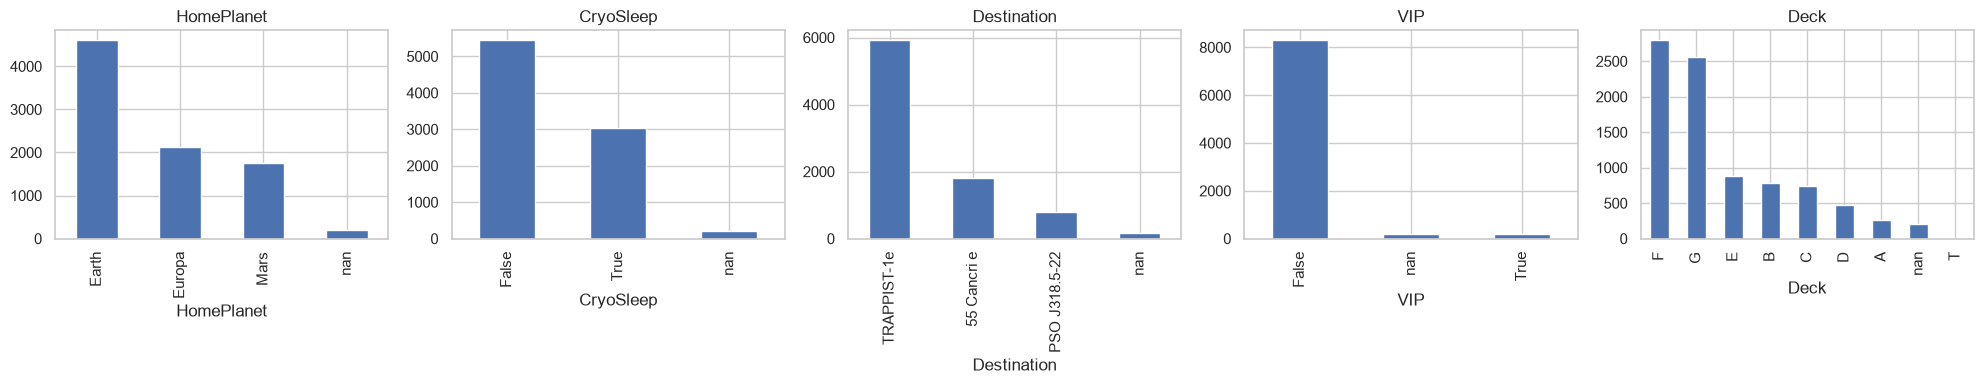

In [22]:
# Grafico de barras de la distribucion de cada columna de baja cardinalidad
fig, axes = plt.subplots(1, len(cat_cols_baja_card), figsize=(4 * len(cat_cols_baja_card), 4))
for col, ax in zip(cat_cols_baja_card, axes):
    train[col].value_counts(dropna=False).plot(kind="bar", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

#### Interpretación — cardinalidad y desbalance

**Cardinalidad alta.** `Name` (8,473 valores únicos, ~97.5% de las 8,693 filas), `Cabin` (6,560, ~75%) y `Group` (6,217, ~71%) tienen cardinalidad extremadamente alta, casi al nivel de un identificador. Usarlas tal cual como categóricas (por ejemplo con one-hot) generaría miles de columnas dummy, la mayoría con una sola observación positiva: no aportarían capacidad de generalización y sí un riesgo severo de sobreajuste. `Cabin` ya se descompuso en sus tres partes (`Deck` con 8 categorías, `Side` binaria, `Num` numérica continua), que sí son manejables. `Group` no se usa como feature en sí: solo sirve de llave temporal para imputar `HomePlanet`/`Deck`/`Side` aprovechando la consistencia dentro de cada grupo de viaje (sección 4), y se descarta del dataset final. `Name` no tiene ninguna descomposición natural útil sin ingeniería adicional (por ejemplo, apellidos para inferir familias), así que se descarta directamente.

**Desbalance extremo.** De las columnas de baja cardinalidad, solo `VIP` muestra un desbalance extremo: entre los valores conocidos, ~97.7% son `False` y ~2.3% `True` (~98/2). Ninguna otra se acerca a ese nivel, la categoría más frecuente de `HomePlanet` (`Earth`) es 52.9%, la de `CryoSleep` (`False`) 62.6%, la de `Destination` (`TRAPPIST-1e`) 68.0% y la de `Deck` (`F`) 32.1%: todas lejos del umbral de >90%.

**¿Binarizar en vez de descartar?** `VIP` ya es binaria por naturaleza (`True`/`False`), así que no hace falta crear un indicador adicional: el desbalance en sí no obliga a descartarla, solo limita cuánta señal puede aportar dado que la categoría minoritaria representa muy pocos casos. La estrategia de binarizar sí tiene sentido para columnas nominales con más de dos categorías cuando una domina de forma aplastante, es exactamente lo que ocurre con `Deck='T'` (ver abajo): en vez de mantenerla como su propia categoría dentro de un one-hot de 8 columnas, conviene colapsarla junto con las demás categorías raras en un grupo `'Otros'`.

**Categorías raras en Deck.** `Deck='T'` aparece en apenas 5 de 8,693 filas de train (0.06%). Una columna indicadora con 5 unos es prácticamente constante: no aporta capacidad predictiva y sí ruido/inestabilidad al ajustar el one-hot. Es la candidata clara a agruparse en `'Otros'` antes de codificar. `Deck='A'` (2.9%, ~256 filas) es igualmente poco frecuente, pero con una muestra suficientemente grande para conservarse como categoría propia sin ese mismo riesgo.


### 2.4 Relación de cada variable con el target

In [23]:
# Crosstab de cada categorica de baja cardinalidad contra el target, normalizado por fila
# (proporcion de Transported=True/False dentro de cada categoria)
for col in cat_cols_baja_card:
    print(f"--- {col} vs Transported ---")
    print(pd.crosstab(train[col], train["Transported"], normalize="index"))
    print()

--- HomePlanet vs Transported ---
Transported     False     True 
HomePlanet                     
Earth        0.576054  0.423946
Europa       0.341154  0.658846
Mars         0.476976  0.523024

--- CryoSleep vs Transported ---
Transported     False     True 
CryoSleep                      
False        0.671079  0.328921
True         0.182417  0.817583

--- Destination vs Transported ---
Transported       False     True 
Destination                      
55 Cancri e    0.390000  0.610000
PSO J318.5-22  0.496231  0.503769
TRAPPIST-1e    0.528825  0.471175

--- VIP vs Transported ---
Transported     False     True 
VIP                            
False        0.493668  0.506332
True         0.618090  0.381910

--- Deck vs Transported ---
Transported     False     True 
Deck                           
A            0.503906  0.496094
B            0.265725  0.734275
C            0.319946  0.680054
D            0.566946  0.433054
E            0.642694  0.357306
F            0.560129  0.4398

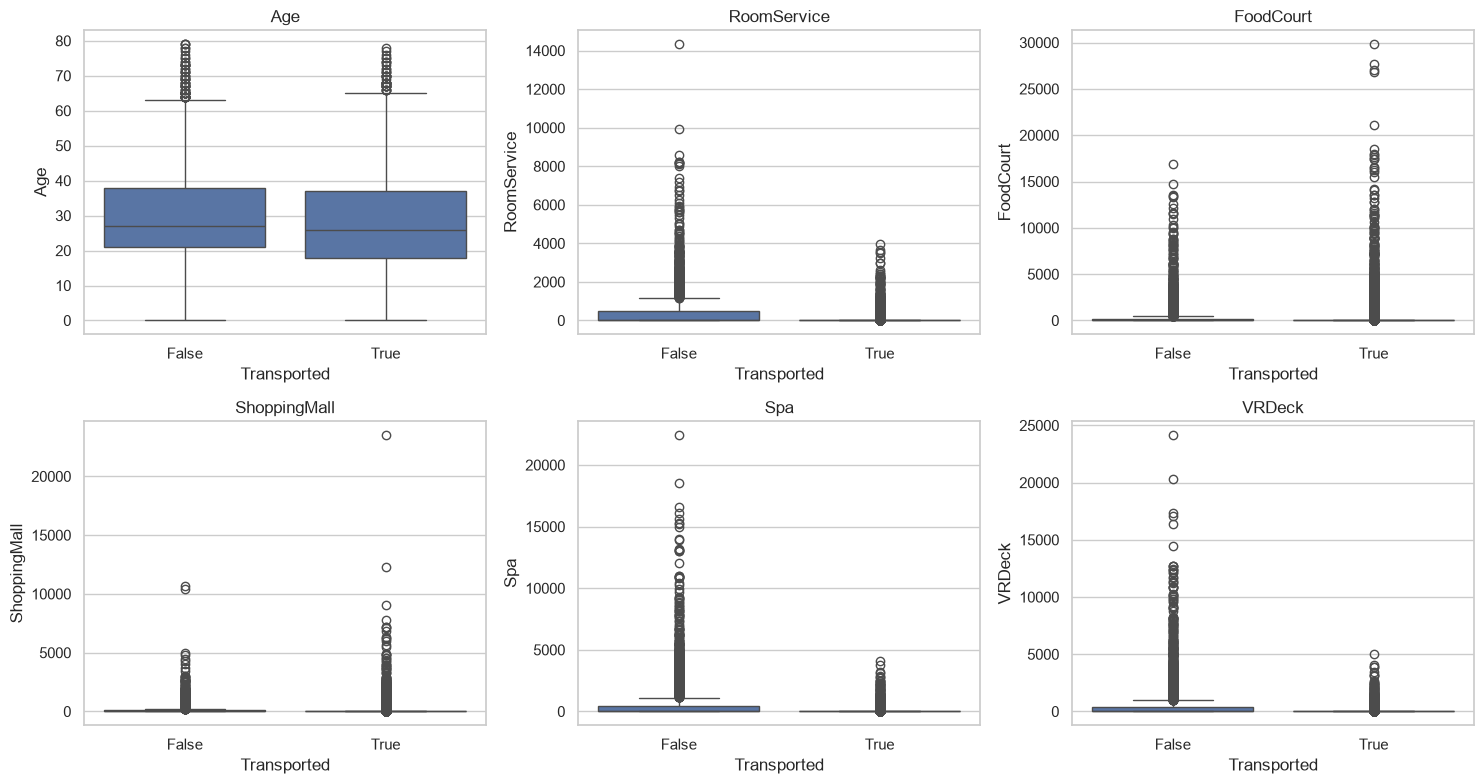

In [24]:
# Boxplots de cada variable numerica separando por el valor del target
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(numeric_cols, axes.flatten()):
    sns.boxplot(x="Transported", y=col, data=train, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

#### Interpretación — relación de cada variable con el target

**Categóricas (crosstab, proporción de `Transported=True` por categoría).**
- **`CryoSleep`** es, por lejos, la más predictiva: 81.8% de los dormidos fueron transportados frente a solo 32.9% de los despiertos — una diferencia de 49 puntos.
- **`HomePlanet`** también diferencia con claridad: `Europa` 65.9% vs. `Earth` 42.4%, con `Mars` en un punto intermedio (52.3%, casi el 50/50 general).
- **`Deck`** diferencia bien pero sin un patrón monótono: `B` (73.4%) y `C` (68.0%) muy por encima del promedio; `D` (43.3%) y `E` (35.7%) muy por debajo; `A` (49.6%), `F` (44.0%) y `G` (51.6%) cerca del 50/50 general (`T` con 20.0% se basa en solo 5 casos y no es una estimación confiable).
- **`Destination`** diferencia de forma más moderada: `55 Cancri e` 61.0% por encima del promedio, `TRAPPIST-1e` 47.1% ligeramente por debajo, `PSO J318.5-22` prácticamente en el 50/50 (50.4%).
- **`VIP`** es la que menos diferencia (50.6% vs. 38.2%) y, sumado a que la categoría `True` representa solo ~2.3% de los datos, es la candidata más débil de las cinco.

**Numéricas (boxplots por valor de Transported).**
- `RoomService`, `Spa` y `VRDeck` muestran el patrón más claro: en los pasajeros `Transported=True` la caja se colapsa casi enteramente sobre 0 (mediana y percentil 75 en 0), mientras que en `Transported=False` la caja es visiblemente más ancha y elevada. Es la misma lógica de `CryoSleep`: quien no gastó (muchas veces porque estaba dormido) tuvo más probabilidad de ser transportado.
- `FoodCourt` y `ShoppingMall` no muestran ese mismo patrón limpio: ambas cajas están comprimidas cerca de 0 en los dos grupos, y de hecho los valores atípicos más altos de `FoodCourt` aparecen del lado `Transported=True` (hasta ~30,000, por encima del máximo de `False`). La relación con el target es mucho menos clara para estas dos.
- `Age` apenas se diferencia entre grupos: medianas y rangos intercuartílicos casi idénticos (`False` ligeramente más alto), sin un desplazamiento visualmente relevante.

**Candidatas fuertes vs. débiles.** Con la evidencia de 2.1 a 2.4 combinada, `CryoSleep` es la variable más fuerte del dataset (además de predecir el target, predice el gasto casi determinísticamente); `HomePlanet` y `Deck` le siguen como buenas candidatas categóricas; `RoomService`, `Spa` y `VRDeck` son las numéricas con relación más clara. `Destination` aporta señal moderada. `VIP`, `Age`, `FoodCourt` y `ShoppingMall` muestran la relación más débil con el target, pero como se discute en la sección 3 una relación débil por sí sola no es motivo suficiente para descartarlas sin evidencia adicional (por ejemplo, de cardinalidad o de faltantes).


## 3. Selección y descarte de variables

In [25]:

resumen_variables = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "pct_faltantes": (train.isna().mean() * 100).round(2),
    "cardinalidad": train.nunique(),
})
resumen_variables.sort_values("pct_faltantes", ascending=False)

,dtype,pct_faltantes,cardinalidad
CryoSleep,object,2.50,2
ShoppingMall,float64,2.39,1115
VIP,object,2.34,2
HomePlanet,str,2.31,3
Name,str,2.30,8473
Deck,object,2.29,8
Cabin,str,2.29,6560
VRDeck,float64,2.16,1306
Spa,float64,2.11,1327
FoodCourt,float64,2.11,1507


In [26]:

for col in cat_cols_baja_card:
    top_prop = train[col].value_counts(normalize=True, dropna=False).iloc[0]
    categoria_top = train[col].value_counts(normalize=True, dropna=False).idxmax()
    print(f"{col}: categoria mas frecuente = {categoria_top!r} ({top_prop:.2%})")

HomePlanet: categoria mas frecuente = 'Earth' (52.94%)
CryoSleep: categoria mas frecuente = False (62.57%)
Destination: categoria mas frecuente = 'TRAPPIST-1e' (68.04%)
VIP: categoria mas frecuente = False (95.38%)
Deck: categoria mas frecuente = 'F' (32.14%)


### Interpretación — selección y descarte de variables

**1. Identificadores y texto libre.** `PassengerId` es un identificador puro (cardinalidad = número de filas); no aporta señal directa como feature, pero su prefijo de grupo se extrae en `Group`, que se usa únicamente como llave temporal para la imputación de la sección 4 y no entra al dataset final. `Name` tiene cardinalidad casi única por fila (8,473/8,693 ≈ 97.5%) y no se encontró ninguna relación aprovechable con el target ni con otra columna sin ingeniería adicional (p. ej. inferir familias por apellido) se descarta.

**2. Alta cardinalidad.** `Cabin` (6,560 valores únicos) y `Group` (6,217) son demasiado granulares para usarse tal cual como categóricas. `Cabin` ya se reemplazó por sus tres componentes `Deck` (8 categorías), `Num` (numérica) y `Side` (binaria) que sí son manejables y, según 2.4, tienen relación visible con el target. `Group` se queda solo como llave interna de imputación y se descarta del dataset final.

**3. Categóricas de baja cardinalidad.** Según los crosstabs de 2.4: `CryoSleep` (82% vs. 33%) y `HomePlanet` (Europa 66% vs. Earth 42%) muestran la relación más clara con `Transported`, seguidas de `Deck` (B/C muy por encima, D/E muy por debajo) y, de forma más moderada, `Destination`. `VIP` es la más débil (51% vs. 38%) y además la única con desbalance extremo (~98/2, sección 2.3). Aun así se conserva: al ser ya binaria no requiere binarizarse el ejemplo de binarización sí aplica a `Deck='T'` (0.06% de los casos), que en vez de mantenerse como categoría propia del one-hot se agrupa en `'Otros'` para no generar una indicadora casi constante.

**4. Numéricas.** Las 5 columnas de gasto se mantienen separadas en vez de combinarse en un `TotalSpend`: 2.2 mostró que tienen sesgos distintos (6.3 a 12.6) y 2.4 reveló que no se relacionan igual con el target `RoomService`, `Spa` y `VRDeck` caen a 0 de forma clara entre los transportados, mientras que `FoodCourt` y `ShoppingMall` no muestran ese mismo patrón (incluso concentran los gastos atípicos más altos del lado `Transported=True`). Combinarlas en una sola variable promediaría esa señal diferenciada y la perdería. `Age` se conserva tal cual: sesgo bajo (0.42) y pocos outliers (0.90%), aunque su relación con el target es débil por sí sola.

**5. Lista final.**

| Variable | Decisión | Justificación (1 línea) |
|---|---|---|
| `PassengerId` | Descartada (cruda) | Solo identificador; se usa para derivar `Group`. |
| `Name` | Descartada | Cardinalidad casi única; sin señal derivable sin ingeniería adicional. |
| `Cabin` | Descartada (cruda), descompuesta | Reemplazada por `Deck`, `Num`, `Side`. |
| `Group` | Uso interno, descartada | Solo llave temporal para imputación por grupo. |
| `HomePlanet` | Incluida | Relación clara con el target (2.4); cardinalidad manejable. |
| `CryoSleep` | Incluida | La relación más fuerte con el target y con el gasto. |
| `Deck` | Incluida | Relación visible con el target; `'T'` agrupada en `'Otros'`. |
| `Num` | Incluida | Numérica manejable, sin problema de sesgo severo. |
| `Side` | Incluida | Diferencia visible en tasa de `Transported` entre `P` y `S`. |
| `Destination` | Incluida | Relación moderada con el target. |
| `Age` | Incluida | Poco sesgo/outliers; relación débil pero sin evidencia para descartarla. |
| `VIP` | Incluida | Desbalance extremo, pero sin evidencia suficiente para justificar su descarte. |
| `RoomService`/`FoodCourt`/`ShoppingMall`/`Spa`/`VRDeck` | Incluidas, por separado | Sesgo alto pero corregible (sección 6); no se combinan porque su relación con el target difiere entre sí. |
| `Transported` | Target | Variable a predecir. |


## 4. Manejo de faltantes

La sección 2.1 mostró dos tipos de faltante muy distintos, y cada uno exige una estrategia distinta:

- **Informativos**: el valor ausente se puede *deducir* de otra columna gracias a una regla del dominio. Imputarlos con la mediana o la moda destruiría información que sí tenemos.
- **Reales**: alrededor de 2% parejo en todas las columnas, sin patrón asociado a ninguna otra variable. Aquí sí corresponde una imputación estadística.

El orden importa: **primero las reglas de dominio, después la imputación estadística**. Si se invierte, la mediana ya habría rellenado los huecos que las reglas podían resolver de forma exacta.

Además se respeta la **disciplina train/test**: todo estadístico (medianas y modas) se aprende *únicamente* de `train` y ese mismo valor se aplica a `test`. Calcular la mediana de `test` con sus propios datos sería fuga de información.

In [27]:
# ---- 4.0 Copias de trabajo y variables derivadas ----------------------------
TARGET = "Transported"
SPEND_COLS = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
NUM_COLS = SPEND_COLS + ["Age", "Num"]
CAT_COLS = ["HomePlanet", "Destination", "Deck", "Side", "CryoSleep", "VIP"]
DESCARTAR = ["PassengerId", "Name", "Cabin"]


def derivar(df):
    """Deriva Group (de PassengerId) y Deck/Num/Side (de Cabin), y descarta las
    columnas originales de alta cardinalidad.

    No usa ningun estadistico aprendido, por lo que puede aplicarse identico a
    train y a test sin riesgo de fuga de informacion.
    """
    d = df.copy()
    d["Group"] = d["PassengerId"].str.split("_").str[0]
    cabina = d["Cabin"].str.split("/", expand=True)
    d["Deck"] = cabina[0]
    d["Num"] = pd.to_numeric(cabina[1], errors="coerce")
    d["Side"] = cabina[2]
    return d.drop(columns=DESCARTAR)


train_p = derivar(train)
test_p = derivar(test)

faltantes_antes = train_p.isna().sum()
print("train_p:", train_p.shape, "| test_p:", test_p.shape)
print("nulos iniciales en train_p:", faltantes_antes.sum())

train_p: (8693, 15) | test_p: (4277, 14)
nulos iniciales en train_p: 2522


In [28]:
def imputar_informativos(df):
    """Rellena los faltantes que se pueden DEDUCIR de otras columnas."""
    d = df.copy()

    dormido = d["CryoSleep"] == True
    for col in SPEND_COLS:
        d.loc[dormido & d[col].isna(), col] = 0.0

    gasto_total = d[SPEND_COLS].sum(axis=1, min_count=1)
    d.loc[d["CryoSleep"].isna() & (gasto_total > 0), "CryoSleep"] = False


    for col in ["HomePlanet", "Deck", "Side"]:
        moda_grupo = d.groupby("Group")[col].transform(
            lambda s: s.mode().iloc[0] if s.notna().any() else np.nan
        )
        d[col] = d[col].fillna(moda_grupo)

    return d


train_p = imputar_informativos(train_p)
test_p = imputar_informativos(test_p)

faltantes_tras_dominio = train_p.isna().sum()
print("nulos en train_p tras las reglas de dominio:", faltantes_tras_dominio.sum())

nulos en train_p tras las reglas de dominio: 1752


In [29]:
def aprender_parametros(df):
    """Devuelve los estadisticos de imputacion calculados sobre train.

    Se usa la MEDIANA en las numericas (no la media) porque las columnas de
    gasto tienen skewness de 6 a 12: la media quedaria arrastrada por la cola.
    """
    return {
        "mediana": {col: df[col].median() for col in NUM_COLS},
        "moda": {col: df[col].mode().iloc[0] for col in CAT_COLS},
    }


params = aprender_parametros(train_p)

print("Medianas aprendidas de train:")
for col, valor in params["mediana"].items():
    print(f"  {col:<14} {valor}")
print("\nModas aprendidas de train:")
for col, valor in params["moda"].items():
    print(f"  {col:<14} {valor!r}")

Medianas aprendidas de train:
  RoomService    0.0
  FoodCourt      0.0
  ShoppingMall   0.0
  Spa            0.0
  VRDeck         0.0
  Age            27.0
  Num            427.0

Modas aprendidas de train:
  HomePlanet     'Earth'
  Destination    'TRAPPIST-1e'
  Deck           'F'
  Side           'S'
  CryoSleep      False
  VIP            False


In [30]:
def imputar_reales(df, params):
    """Aplica los parametros APRENDIDOS DE TRAIN. Esta funcion no calcula ningun
    estadistico por su cuenta: por eso es imposible que filtre informacion de test."""
    d = df.copy()
    for col, valor in {**params["mediana"], **params["moda"]}.items():
        d[col] = d[col].fillna(valor)

    for col in ["CryoSleep", "VIP"]:
        d[col] = d[col].astype(bool)

    return d.drop(columns="Group")


train_p = imputar_reales(train_p, params)
test_p = imputar_reales(test_p, params)

reporte = pd.DataFrame({
    "faltantes_iniciales": faltantes_antes,
    "resueltos_por_dominio": faltantes_antes - faltantes_tras_dominio,
    "resueltos_por_estadistico": faltantes_tras_dominio,
})
reporte = reporte[reporte["faltantes_iniciales"] > 0]
reporte["pct_por_dominio"] = (
    100 * reporte["resueltos_por_dominio"] / reporte["faltantes_iniciales"]
).round(1)
reporte.sort_values("resueltos_por_dominio", ascending=False)

,faltantes_iniciales,resueltos_por_dominio,resueltos_por_estadistico,pct_por_dominio
CryoSleep,217,119,98,54.8
Deck,199,100,99,50.3
Side,199,100,99,50.3
ShoppingMall,208,96,112,46.2
HomePlanet,201,90,111,44.8
FoodCourt,183,70,113,38.3
RoomService,181,68,113,37.6
Spa,183,65,118,35.5
VRDeck,188,62,126,33.0
VIP,203,0,203,0.0


In [31]:
# ---- 4.4 Verificacion del manejo de faltantes -------------------------------
for nombre, d in [("train_p", train_p), ("test_p", test_p)]:
    print(f"{nombre}: nulos={d.isna().sum().sum()} | shape={d.shape}")

mismas = list(train_p.drop(columns=TARGET).columns) == list(test_p.columns)
print("\ntrain y test tienen las mismas columnas (sin el target):", mismas)

print("Columnas object por codificar:", list(train_p.select_dtypes(include="object").columns))

train_p: nulos=0 | shape=(8693, 14)
test_p: nulos=0 | shape=(4277, 13)

train y test tienen las mismas columnas (sin el target): True
Columnas object por codificar: ['HomePlanet', 'Destination', 'Deck', 'Side']


#### Interpretación — estrategia de imputación

**Faltantes informativos (resueltos con reglas del dominio, sin inventar valores).**

1. **Gastos con `CryoSleep=True` → 0.** La celda 2.1 confirmó que los 5 rubros suman exactamente **0** para todo pasajero en criosueño: nadie dormido consumió nada. Un gasto ausente en ese subgrupo no es un valor desconocido, es un cero no registrado. Esta regla resolvió **361 de los 943** gastos faltantes.
2. **`CryoSleep` faltante con gasto > 0 → `False`.** La misma regla aplicada al revés: ningún pasajero en criosueño registró gasto, así que quien gastó no pudo estar dormido. Recuperó **119 de los 217** faltantes de `CryoSleep` sin recurrir a la moda.
3. **`HomePlanet`, `Deck` y `Side` → valor del grupo de viaje.** `PassengerId` tiene formato `gggg_pp`, donde `gggg` identifica al grupo. Al verificar la consistencia interna: **0 de 6217 grupos** tienen más de un `HomePlanet`, y lo mismo ocurre con `Side`. En `Deck` la regla no es perfecta (421 grupos con más de un valor, ~7%), pero sigue siendo ampliamente mayoritaria, por lo que se usa la moda del grupo. Entre las tres se recuperaron **290 faltantes** con información real del propio dataset.

**Faltantes reales (imputación estadística).**

Las columnas `Age`, `Destination`, `VIP` y `Num` no tienen ninguna relación lógica con otra variable que permita deducir su valor: su ausencia es del ~2% y está repartida de forma uniforme, consistente con faltantes inyectados al azar (MCAR). Para ellas, y para lo que quedó de las anteriores:

- **Numéricas → mediana.** No la media: los 5 rubros de gasto tienen skewness entre 6.3 y 12.6, y la media quedaría arrastrada por la cola de gastadores extremos. La mediana de todos los gastos es `0.0`, coherente con que ~63% de los registros son cero.
- **Categóricas → moda.** Con solo ~2% de faltantes, asumir la categoría mayoritaria introduce un sesgo despreciable. Con un porcentaje alto habría sido preferible una categoría `"Desconocido"`, que no asume nada; aquí no se justifica añadir una categoría más al one-hot por tan pocos casos.

**Disciplina train/test.** Las medianas y modas se calculan en `aprender_parametros(train_p)` y se guardan en el diccionario `params`. La función `imputar_reales` **no contiene ninguna llamada a `.median()` ni `.mode()`**: solo aplica los valores recibidos. Por construcción, entonces, es imposible que `test` se impute con sus propios estadísticos. Se verificó además que los grupos de viaje **no se comparten** entre train y test (0 grupos en común), por lo que la imputación por grupo del punto 3 tampoco cruza información entre conjuntos.

**Resultado:** 0 nulos en train y en test, con las mismas columnas en ambos.

## 5. Codificación de variables categóricas

Tras la sección 4 quedan seis variables categóricas: dos booleanas (`CryoSleep`, `VIP`) y cuatro de texto (`HomePlanet`, `Destination`, `Deck`, `Side`). Ninguna es **ordinal**: aunque `Deck` use letras A–G y parezca tener un orden natural, el crosstab de la sección 2.4 muestra que la proporción de `Transported` **no** es monótona a lo largo de esas letras (B 73%, D 43%, G 52%). Codificarla como 1…7 impondría una relación de orden y magnitud que los datos no respaldan, así que se tratan **todas como nominales**.

La codificación se ajusta (`fit`) **solo sobre train** y se aplica (`transform`) a ambos conjuntos, igual que en la sección 4.

In [32]:
BOOL_COLS = ["CryoSleep", "VIP"]
CAT_NOMINALES = ["HomePlanet", "Destination", "Deck", "Side"]


def preparar_categoricas(df):
    """Booleanas a enteros y agrupacion de la categoria rara de Deck."""
    d = df.copy()

    for col in BOOL_COLS:
        d[col] = d[col].astype(int)

    d["Deck"] = d["Deck"].replace("T", "Otros")

    return d


train_e = preparar_categoricas(train_p)
test_e = preparar_categoricas(test_p)

print("Categorias de Deck tras agrupar:", sorted(train_e["Deck"].unique()))
print("dtypes de las booleanas:", {c: str(train_e[c].dtype) for c in BOOL_COLS})

Categorias de Deck tras agrupar: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'Otros']
dtypes de las booleanas: {'CryoSleep': 'int64', 'VIP': 'int64'}


In [33]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="if_binary")
ohe.fit(train_e[CAT_NOMINALES])

print("Categorias aprendidas de train:")
for col, cats in zip(CAT_NOMINALES, ohe.categories_):
    print(f"  {col:<12} {list(cats)}")


def aplicar_ohe(df, ohe):
    """Sustituye las columnas nominales por sus indicadoras 0/1."""
    d = df.copy()
    matriz = ohe.transform(d[CAT_NOMINALES])
    nombres = ohe.get_feature_names_out(CAT_NOMINALES)
    dummies = pd.DataFrame(matriz, columns=nombres, index=d.index).astype(int)
    return pd.concat([d.drop(columns=CAT_NOMINALES), dummies], axis=1)


train_e = aplicar_ohe(train_e, ohe)
test_e = aplicar_ohe(test_e, ohe)

print("\ntrain_e:", train_e.shape, "| test_e:", test_e.shape)

Categorias aprendidas de train:
  HomePlanet   ['Earth', 'Europa', 'Mars']
  Destination  ['55 Cancri e', 'PSO J318.5-22', 'TRAPPIST-1e']
  Deck         ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'Otros']
  Side         ['P', 'S']

train_e: (8693, 25) | test_e: (4277, 24)


In [34]:
objects = list(train_e.select_dtypes(include="object").columns)
print("Columnas de tipo object restantes:", objects if objects else "ninguna")

mismas = list(train_e.drop(columns=TARGET).columns) == list(test_e.columns)
print("train y test tienen las mismas columnas (sin el target):", mismas)

print("\nColumnas generadas por el one-hot:")
for c in ohe.get_feature_names_out(CAT_NOMINALES):
    print("  ", c)

train_e.head()

Columnas de tipo object restantes: ninguna
train y test tienen las mismas columnas (sin el target): True

Columnas generadas por el one-hot:
   HomePlanet_Earth
   HomePlanet_Europa
   HomePlanet_Mars
   Destination_55 Cancri e
   Destination_PSO J318.5-22
   Destination_TRAPPIST-1e
   Deck_A
   Deck_B
   Deck_C
   Deck_D
   Deck_E
   Deck_F
   Deck_G
   Deck_Otros
   Side_S


,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Num,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_Otros,Side_S
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,False,0.0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,True,0.0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,0.0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,0.0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,True,1.0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1


#### Interpretación — estrategia de codificación

**Por tipo de variable:**

| Variable | Tipo | Codificación | Justificación |
|---|---|---|---|
| `CryoSleep`, `VIP` | binaria | `astype(int)` | Ya son binarias; el one-hot solo duplicaría información. |
| `Side` | nominal, 2 cat. | one-hot con `drop="if_binary"` → 1 columna | Con dos categorías, la segunda columna es el complemento exacto de la primera: redundante y fuente de multicolinealidad. |
| `HomePlanet`, `Destination` | nominal, 3 cat. | one-hot completo (3 columnas c/u) | Sin orden natural entre planetas ni destinos. Se conservan las 3 para no imponer una categoría como base. |
| `Deck` | nominal, 8 cat. | one-hot completo | Ver abajo: se descartó tratarla como ordinal. |

**Por qué ninguna se codificó como ordinal.** `Deck` es la única candidata: sus valores A–G sugieren un orden físico dentro de la nave. Pero un *label encoding* 1…7 le diría al modelo que la distancia entre A y B es la misma que entre F y G, y que G "vale más" que A. El crosstab de 2.4 desmiente esa estructura: la proporción de `Transported` va 50% (A), 73% (B), 68% (C), 43% (D), 36% (E), 44% (F), 52% (G) — sube y baja sin monotonía. No hay evidencia de orden, así que se trata como nominal.

**Agrupación de categorías raras.** `Deck='T'` aparece en 5 registros de train (0.06%) y 6 de test. Una indicadora con 5 unos entre 8693 filas es prácticamente constante: no aporta capacidad predictiva y sí ruido. Se agrupa en `'Otros'`, que es la recomendación del análisis de desbalance de la sección 2.3.

**Robustez train/test.** `OneHotEncoder` se ajusta solo con `train` y su parámetro `handle_unknown="ignore"` garantiza que una categoría no vista en test se codifique como ceros en lugar de detener el pipeline. Esto es justamente lo que `pd.get_dummies` **no** hace: aplicado por separado a train y test produciría un número distinto de columnas en cada uno.

**Resultado:** 25 columnas en train (24 + target), 24 en test, las mismas y en el mismo orden, y **cero columnas de tipo `object`**.

## 6. Transformación de variables numéricas

La sección 2.2 midió el sesgo de las variables numéricas. Aquí se decide, **con un criterio explícito y no a ojo**, cuáles se transforman: se aplica la transformación a toda variable con `|skew| > 1`, umbral convencional para considerar una distribución fuertemente asimétrica.

No transformar también es una decisión, y se justifica igual que transformar.

In [35]:
UMBRAL_SKEW = 1.0

skew_antes = train_e[NUM_COLS].skew().sort_values(ascending=False)
A_TRANSFORMAR = [c for c in NUM_COLS if abs(skew_antes[c]) > UMBRAL_SKEW]

print("Skewness de las variables numericas:")
for col, valor in skew_antes.items():
    marca = "-> se transforma" if col in A_TRANSFORMAR else "   se deja igual"
    print(f"  {col:<14} {valor:>7.2f}  {marca}")

Skewness de las variables numericas:
  ShoppingMall     12.76  -> se transforma
  VRDeck            7.90  -> se transforma
  Spa               7.72  -> se transforma
  FoodCourt         7.18  -> se transforma
  RoomService       6.40  -> se transforma
  Num               0.75     se deja igual
  Age               0.43     se deja igual


In [36]:
def transformar_sesgo(df, cols):
    """Aplica log1p = log(1 + x) a las columnas indicadas.

    Se usa log1p y NO log porque ~63% de los registros de gasto valen exactamente
    0, y log(0) = -inf. log1p esta definida en 0 y devuelve 0.

    No aprende ningun parametro de los datos, asi que aplicarla a train y test por
    separado no genera fuga de informacion.
    """
    d = df.copy()
    for col in cols:
        d[col] = np.log1p(d[col])
    return d


train_t = transformar_sesgo(train_e, A_TRANSFORMAR)
test_t = transformar_sesgo(test_e, A_TRANSFORMAR)

comparacion = pd.DataFrame({
    "skew_antes": skew_antes[A_TRANSFORMAR],
    "skew_despues": train_t[A_TRANSFORMAR].skew(),
})
comparacion["reduccion_%"] = (
    100 * (1 - comparacion["skew_despues"].abs() / comparacion["skew_antes"].abs())
).round(1)
comparacion.round(2)

,skew_antes,skew_despues,reduccion_%
RoomService,6.40,1.15,82.0
FoodCourt,7.18,1.14,84.1
ShoppingMall,12.76,1.24,90.3
Spa,7.72,1.12,85.5
VRDeck,7.90,1.19,84.9


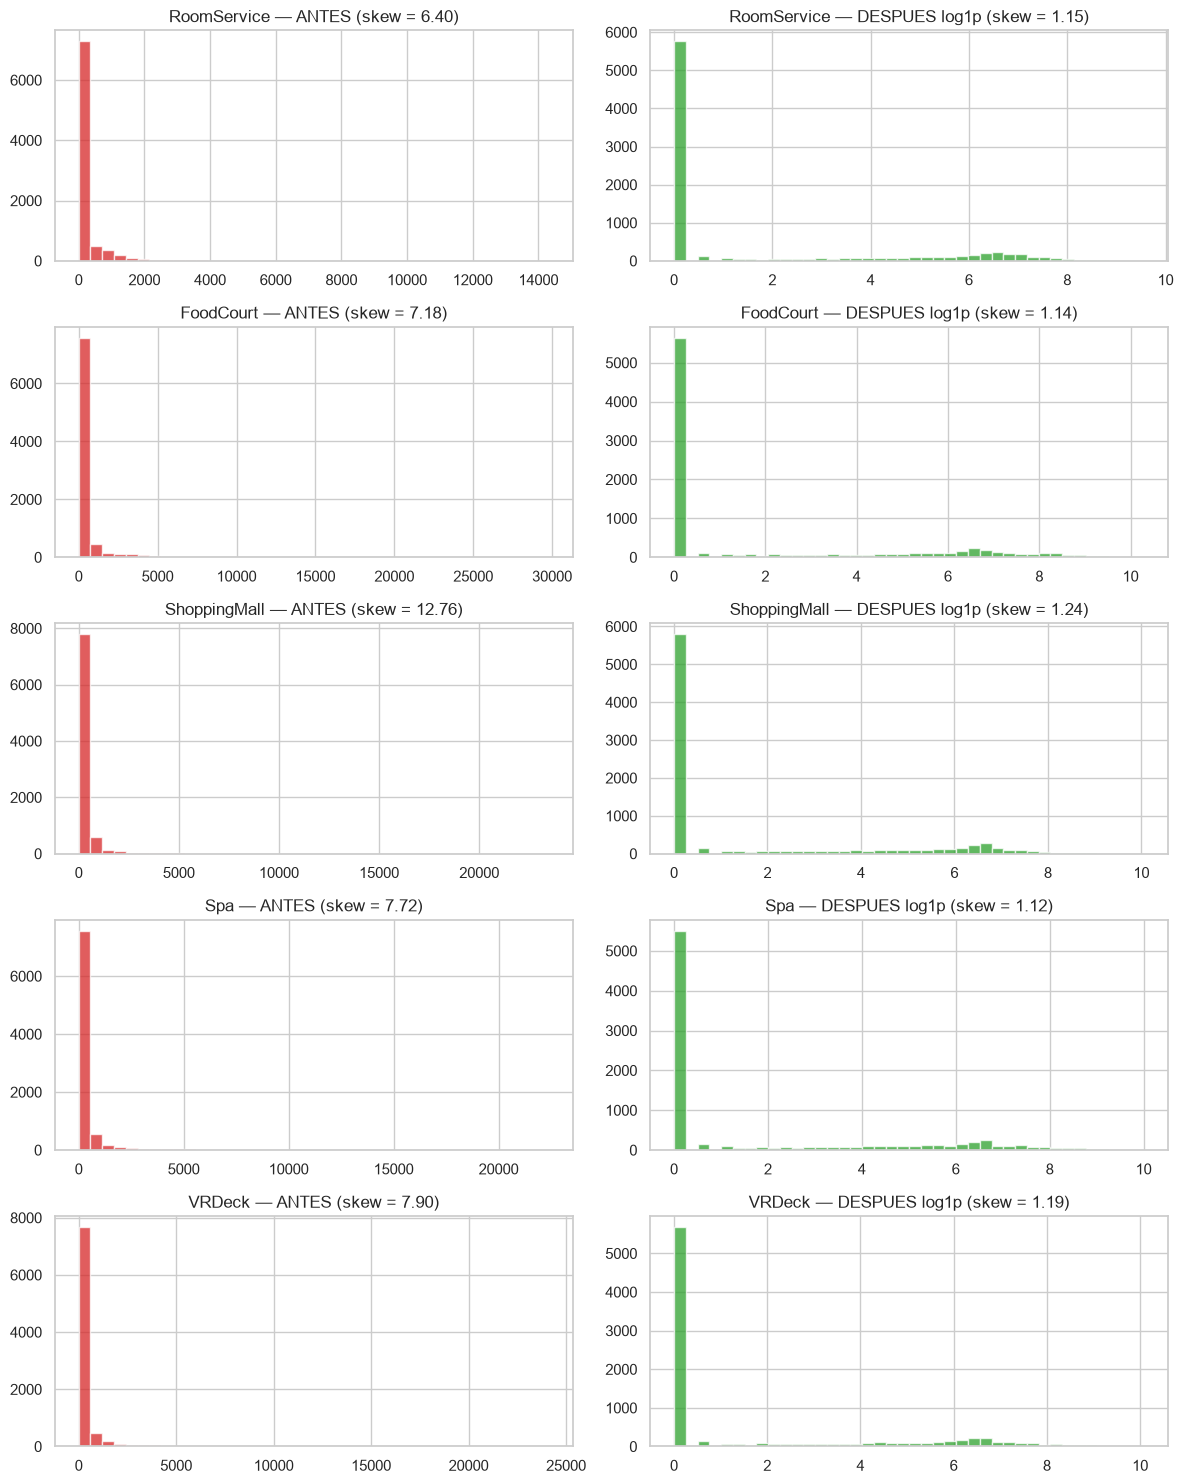

In [37]:
fig, axes = plt.subplots(len(A_TRANSFORMAR), 2, figsize=(12, 3 * len(A_TRANSFORMAR)))

for fila, col in enumerate(A_TRANSFORMAR):
    train_e[col].hist(bins=40, ax=axes[fila, 0], color="tab:red", alpha=0.75)
    axes[fila, 0].set_title(f"{col} — ANTES (skew = {skew_antes[col]:.2f})")

    train_t[col].hist(bins=40, ax=axes[fila, 1], color="tab:green", alpha=0.75)
    axes[fila, 1].set_title(f"{col} — DESPUES log1p (skew = {train_t[col].skew():.2f})")

plt.tight_layout()
plt.show()

#### Interpretación — transformación de variables numéricas

**Qué se transformó y qué no.** Con el criterio `|skew| > 1`:

- **Se transforman los 5 rubros de gasto** (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`), con sesgos de 6.4 a 12.8. Son distribuciones donde la inmensa mayoría vale 0 y unos pocos pasajeros gastan decenas de miles.
- **`Age` (skew 0.43) y `Num` (skew 0.75) se dejan intactas.** Ambas están por debajo del umbral: `Age` es casi simétrica y `Num` tiene una asimetría leve. Transformarlas solo distorsionaría variables que ya están bien condicionadas.

**Por qué `log1p` y no `log`.** Aproximadamente el **63%** de los registros de gasto valen exactamente 0, y `log(0) = -inf`. `log1p` calcula `log(1 + x)`, está definida en 0 y devuelve 0, preservando esas filas sin introducir infinitos ni tener que sumar una constante arbitraria.

**Efecto medido.** El sesgo cae entre 82% y 90%:

| Variable | Antes | Después | Reducción |
|---|---|---|---|
| RoomService | 6.40 | 1.15 | 82.0% |
| FoodCourt | 7.18 | 1.14 | 84.1% |
| ShoppingMall | 12.76 | 1.24 | 90.3% |
| Spa | 7.72 | 1.12 | 85.5% |
| VRDeck | 7.90 | 1.19 | 84.9% |

**Por qué el sesgo residual no baja de ~1.1.** Los histogramas lo explican: `log1p` comprime la cola larga (el eje pasa de 0–30,000 a 0–10) y hace visible la distribución real de quienes sí gastaron, pero **no puede eliminar la barra en cero**, que concentra el 63% de los datos. Ese sesgo remanente no es una cola pesada sino *exceso de ceros* (zero-inflation), y ninguna transformación monótona lo corrige. Si se quisiera modelar explícitamente, la vía sería añadir una indicadora binaria del tipo `HaGastado`, no otra transformación.

**Sin fuga de información.** A diferencia de la imputación y el escalado, `log1p` es una función fija que no estima ningún parámetro a partir de los datos. Aplicarla a train y test por separado es seguro por construcción.

## 7. Escalado

Las variables numéricas quedaron en escalas muy distintas: `Num` llega a 1894, `Age` a 79 y los gastos transformados a ~10. Los modelos basados en distancia (KNN, SVM) y los que usan regularización (regresión logística) quedarían dominados por la variable de mayor rango, así que hace falta escalar.

Se escalan **únicamente las 7 columnas numéricas**. Las indicadoras 0/1 del one-hot y las binarias `CryoSleep`/`VIP` ya están en una escala comparable, y escalarlas destruiría su interpretación directa.

La elección del escalador se toma con evidencia, no por costumbre: primero se vuelve a medir la presencia de outliers **después** de la transformación de la sección 6, y luego se comparan los dos candidatos.

In [38]:
# ---- 7.1 Los outliers DESPUES de la transformacion --------------------------

filas = []
for col in NUM_COLS:
    q1, q3 = train_t[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    fuera = ((train_t[col] < q1 - 1.5 * iqr) | (train_t[col] > q3 + 1.5 * iqr)).mean() * 100
    filas.append({
        "columna": col, "Q1": q1, "mediana": train_t[col].median(), "Q3": q3,
        "IQR": iqr, "pct_outliers": round(fuera, 1),
        "min": train_t[col].min(), "max": train_t[col].max(),
    })

pd.DataFrame(filas).round(2)

,columna,Q1,mediana,Q3,IQR,pct_outliers,min,max
0,RoomService,0.0,0.0,3.74,3.74,0.0,0.0,9.57
1,FoodCourt,0.0,0.0,4.13,4.13,0.0,0.0,10.30
2,ShoppingMall,0.0,0.0,3.14,3.14,0.8,0.0,10.06
3,Spa,0.0,0.0,3.99,3.99,0.0,0.0,10.02
4,VRDeck,0.0,0.0,3.71,3.71,0.3,0.0,10.09
5,Age,20.0,27.0,37.00,17.00,1.9,0.0,79.00
6,Num,173.0,427.0,983.00,810.00,0.0,0.0,1894.00


In [39]:
# ---- 7.2 Comparacion de los dos escaladores candidatos ----------------------
from sklearn.preprocessing import RobustScaler, StandardScaler

cero = pd.DataFrame([[0.0] * len(NUM_COLS)], columns=NUM_COLS)

comparacion_esc = {}
for nombre, Escalador in [("RobustScaler", RobustScaler), ("StandardScaler", StandardScaler)]:
    esc = Escalador().fit(train_t[NUM_COLS])
    comparacion_esc[nombre] = pd.Series(esc.transform(cero)[0], index=NUM_COLS)

pd.DataFrame(comparacion_esc).round(3)

,RobustScaler,StandardScaler
RoomService,0.000,-0.638
FoodCourt,0.000,-0.650
ShoppingMall,0.000,-0.623
Spa,0.000,-0.664
VRDeck,0.000,-0.640
Age,-1.588,-2.008
Num,-0.527,-1.177


In [40]:
# ---- 7.3 Aplicacion del RobustScaler ----------------------------------------
escalador = RobustScaler()
escalador.fit(train_t[NUM_COLS])


def escalar(df, escalador):
    """Escala unicamente las columnas numericas continuas.

    Las indicadoras 0/1 se dejan intactas: ya estan en escala comparable y
    escalarlas eliminaria su lectura directa como presencia/ausencia.
    """
    d = df.copy()
    d[NUM_COLS] = escalador.transform(d[NUM_COLS])
    return d


train_s = escalar(train_t, escalador)
test_s = escalar(test_t, escalador)

print("Parametros aprendidos de train:")
for col, centro, escala in zip(NUM_COLS, escalador.center_, escalador.scale_):
    print(f"  {col:<14} mediana={centro:>8.2f}   IQR={escala:>8.2f}")

Parametros aprendidos de train:
  RoomService    mediana=    0.00   IQR=    3.74
  FoodCourt      mediana=    0.00   IQR=    4.13
  ShoppingMall   mediana=    0.00   IQR=    3.14
  Spa            mediana=    0.00   IQR=    3.99
  VRDeck         mediana=    0.00   IQR=    3.71
  Age            mediana=   27.00   IQR=   17.00
  Num            mediana=  427.00   IQR=  810.00


In [41]:
# ---- 7.4 Verificacion del escalado ------------------------------------------
print("train_s:", train_s.shape, "| test_s:", test_s.shape)
print("nulos:", train_s.isna().sum().sum(), "/", test_s.isna().sum().sum())

print("\nRango de las numericas tras escalar (train):")
print(train_s[NUM_COLS].agg(["min", "median", "max"]).round(2).T)

# Las indicadoras deben seguir siendo estrictamente 0/1
indicadoras = [c for c in train_s.columns if c not in NUM_COLS + [TARGET]]
valores = set(np.unique(train_s[indicadoras].values))
print("\nValores presentes en las indicadoras:", valores)

train_s: (8693, 25) | test_s: (4277, 24)
nulos: 0 / 0

Rango de las numericas tras escalar (train):
               min  median   max
RoomService   0.00     0.0  2.56
FoodCourt     0.00     0.0  2.50
ShoppingMall  0.00     0.0  3.21
Spa           0.00     0.0  2.51
VRDeck        0.00     0.0  2.72
Age          -1.59     0.0  3.06
Num          -0.53     0.0  1.81

Valores presentes en las indicadoras: {np.int64(0), np.int64(1)}


#### Interpretación — elección del escalador

**Por qué hay que escalar.** Las 7 numéricas quedaron en rangos incomparables: `Num` llega a 1894, `Age` a 79 y los gastos transformados a ~10. Sin escalar, cualquier modelo que use distancias o regularización trataría a `Num` como ~190 veces más importante que un gasto, solo por su unidad de medida.

**Qué se escala y qué no.** Solo las 7 columnas numéricas continuas. Las 15 indicadoras del one-hot y las binarias `CryoSleep`/`VIP` ya viven en [0, 1]: escalarlas no corrige ningún desbalance de escala y sí destruye su lectura directa como presencia/ausencia.

**Por qué `RobustScaler` y no `StandardScaler`.** La sección 2.2 detectó ~21% de outliers por regla de Tukey en las columnas de gasto, lo que apuntaría de inmediato a un escalador robusto. Pero esa medición era sobre los datos crudos, y la celda 7.1 muestra que **después de `log1p` los outliers caen a menos del 2%**. Con ese dato solo, `StandardScaler` sería defendible. La decisión se sostiene en dos argumentos que siguen vigentes:

1. **El punto cero tiene significado y hay que preservarlo.** En las columnas de gasto, el valor 0 no es un número más: significa "este pasajero no consumió nada", y describe al ~65% de los registros. Como la mediana de esas columnas es exactamente 0, `RobustScaler` (que resta la mediana) deja ese 0 en **0.0**. `StandardScaler` (que resta la media) lo manda a **−0.638**, un valor arbitrario que además queda por debajo del de un pasajero que sí gastó poco. La celda 7.2 lo muestra explícitamente:

   | Columna | RobustScaler | StandardScaler |
   |---|---|---|
   | RoomService | **0.000** | −0.638 |
   | FoodCourt | **0.000** | −0.650 |
   | Spa | **0.000** | −0.664 |

2. **Las distribuciones siguen sin ser normales.** Aunque la cola larga desapareció, persiste el exceso de ceros: en los 5 gastos `Q1 = mediana = 0`. La media y la desviación estándar que usa `StandardScaler` asumen una distribución aproximadamente simétrica y no describen bien una masa puntual de ese tamaño. La mediana y el IQR sí.

Adicionalmente, `Age` conserva 1.9% de outliers legítimos (pasajeros de hasta 79 años) que no se eliminaron por ser información válida, y el escalador robusto evita que compriman al resto de la distribución.

**Disciplina train/test.** `escalador.fit()` se ejecuta solo sobre `train_t`. Los parámetros aprendidos (`center_` = medianas, `scale_` = IQR) se aplican tal cual a test mediante `transform`, siguiendo el mismo principio de las secciones 4 y 5.

## 8. Verificación final

Se verifica sobre `train_s` y `test_s` — el resultado de encadenar las secciones 4 (faltantes), 5 (codificación), 6 (transformación) y 7 (escalado) — que no queden nulos, que no queden columnas de tipo `object`, y se reporta el shape final.

In [42]:
final_train_nulos = train_s.isna().sum().sum()
final_test_nulos = test_s.isna().sum().sum()
final_train_objects = list(train_s.select_dtypes(include="object").columns)
final_test_objects = list(test_s.select_dtypes(include="object").columns)

print("== Nulos ==")
print(f"train_s: {final_train_nulos} nulos")
print(f"test_s:  {final_test_nulos} nulos")

print("\n== Columnas de tipo object ==")
print(f"train_s: {final_train_objects if final_train_objects else 'ninguna'}")
print(f"test_s:  {final_test_objects if final_test_objects else 'ninguna'}")

print("\n== Shape final ==")
print(f"train_s: {train_s.shape}  (incluye la columna target '{TARGET}')")
print(f"test_s:  {test_s.shape}")

mismas_cols = list(train_s.drop(columns=TARGET).columns) == list(test_s.columns)
print(f"\ntrain_s y test_s tienen las mismas columnas, en el mismo orden (sin el target): {mismas_cols}")

assert final_train_nulos == 0 and final_test_nulos == 0, "Aun quedan valores nulos"
assert not final_train_objects and not final_test_objects, "Aun quedan columnas de tipo object"
assert mismas_cols, "train y test no coinciden en columnas"
print("\nOK: verificacion superada - sin nulos, sin columnas object, mismas columnas en train/test, listo para modelar.")

== Nulos ==
train_s: 0 nulos
test_s:  0 nulos

== Columnas de tipo object ==
train_s: ninguna
test_s:  ninguna

== Shape final ==
train_s: (8693, 25)  (incluye la columna target 'Transported')
test_s:  (4277, 24)

train_s y test_s tienen las mismas columnas, en el mismo orden (sin el target): True

OK: verificacion superada - sin nulos, sin columnas object, mismas columnas en train/test, listo para modelar.


### 8.1 Tabla resumen de decisiones

In [43]:
resumen_final = pd.DataFrame([
    ("PassengerId", "Identificador", "Descartada (cruda)",
     "Cardinalidad = numero de filas; se uso unicamente para derivar 'Group', que a su vez solo sirvio como llave temporal de imputacion (seccion 4)."),
    ("Name", "Texto libre", "Descartada",
     "Cardinalidad casi unica por fila; no se encontro senal derivable sin ingenieria adicional (ver seccion 3)."),
    ("Cabin", "Texto compuesto (deck/num/side)", "Descartada (cruda), descompuesta",
     "Se reemplazo por Deck, Num y Side: mismas variables con cardinalidad manejable y con relacion visible con el target (seccion 2.4)."),
    ("Group (derivada de PassengerId)", "Categorica de alta cardinalidad", "Uso interno, descartada del dataset final",
     "0/6217 grupos con mas de un HomePlanet o Side: se uso para imputar por moda de grupo (seccion 4) y se elimina en imputar_reales()."),
    ("HomePlanet", "Nominal, 3 categorias", "Imputacion por grupo + moda; One-Hot (3 columnas)",
     "~2.3% de faltantes reales; imputacion por grupo resuelve la mayoria sin inventar valores; relacion clara con Transported (seccion 2.4)."),
    ("CryoSleep", "Binaria", "Regla de dominio (gasto>0 => False) + moda; astype(int)",
     "Variable con la relacion mas fuerte con el target; determina casi deterministicamente el gasto en servicios (seccion 2.1)."),
    ("Deck (derivada de Cabin)", "Nominal, 8 categorias (T renombrada a 'Otros')", "Imputacion por grupo + moda; categoria 'T' agrupada en 'Otros'; One-Hot",
     "Regla de grupo mayoritaria (~93% de grupos comparten Deck); 'T' representa <0.1% de los casos y se agrupa para evitar una indicadora casi constante (seccion 2.3)."),
    ("Num (derivada de Cabin)", "Numerica continua", "Imputacion mediana; sin transformar (skew=0.75 < umbral); RobustScaler",
     "Faltante real (~2%); skew por debajo del umbral de 1.0 definido en la seccion 6, no requiere log1p."),
    ("Side (derivada de Cabin)", "Binaria (P/S)", "Imputacion por grupo + moda; One-Hot con drop='if_binary' (1 columna)",
     "0/6217 grupos con mas de un Side; diferencia visible en tasa de Transported entre P y S (seccion 2.4)."),
    ("Destination", "Nominal, 3 categorias", "Imputacion moda; One-Hot (3 columnas)",
     "Faltante real (~2%), sin relacion logica con otra columna; relacion moderada con el target."),
    ("Age", "Numerica continua", "Imputacion mediana; sin transformar (skew=0.43); RobustScaler",
     "Faltante real (~2%, sin patron); distribucion casi simetrica, no requiere log1p."),
    ("VIP", "Binaria, desbalance extremo (~98/2)", "Imputacion moda; astype(int)",
     "Faltante real (~2%); pese al fuerte desbalance se conserva porque no hay evidencia suficiente para descartarla sin justificacion (seccion 3)."),
    ("RoomService / FoodCourt / ShoppingMall / Spa / VRDeck", "Numericas continuas", "Imputacion condicional (0 si CryoSleep=True, mediana en otro caso); log1p (skew original 6.4-12.8); RobustScaler",
     "Faltante informativo confirmado empiricamente (gasto=0 en el 100% de los CryoSleep=True); alto skew y exceso de ceros -> log1p + RobustScaler preserva el 0 como 0 (secciones 2.1, 6 y 7)."),
    ("Transported", "Booleana (target)", "Sin imputacion ni transformacion",
     "Variable a predecir; ausente en test.csv por diseno de la competencia de Kaggle."),
], columns=["Variable", "Tipo", "Tratamiento aplicado", "Justificacion"])

pd.set_option("display.max_colwidth", None)
resumen_final

,Variable,Tipo,Tratamiento aplicado,Justificacion
0,PassengerId,Identificador,Descartada (cruda),"Cardinalidad = numero de filas; se uso unicamente para derivar 'Group', que a su vez solo sirvio como llave temporal de imputacion (seccion 4)."
1,Name,Texto libre,Descartada,Cardinalidad casi unica por fila; no se encontro senal derivable sin ingenieria adicional (ver seccion 3).
2,Cabin,Texto compuesto (deck/num/side),"Descartada (cruda), descompuesta","Se reemplazo por Deck, Num y Side: mismas variables con cardinalidad manejable y con relacion visible con el target (seccion 2.4)."
3,Group (derivada de PassengerId),Categorica de alta cardinalidad,"Uso interno, descartada del dataset final",0/6217 grupos con mas de un HomePlanet o Side: se uso para imputar por moda de grupo (seccion 4) y se elimina en imputar_reales().
4,HomePlanet,"Nominal, 3 categorias",Imputacion por grupo + moda; One-Hot (3 columnas),~2.3% de faltantes reales; imputacion por grupo resuelve la mayoria sin inventar valores; relacion clara con Transported (seccion 2.4).
5,CryoSleep,Binaria,Regla de dominio (gasto>0 => False) + moda; astype(int),Variable con la relacion mas fuerte con el target; determina casi deterministicamente el gasto en servicios (seccion 2.1).
6,Deck (derivada de Cabin),"Nominal, 8 categorias (T renombrada a 'Otros')",Imputacion por grupo + moda; categoria 'T' agrupada en 'Otros'; One-Hot,Regla de grupo mayoritaria (~93% de grupos comparten Deck); 'T' representa <0.1% de los casos y se agrupa para evitar una indicadora casi constante (seccion 2.3).
7,Num (derivada de Cabin),Numerica continua,Imputacion mediana; sin transformar (skew=0.75 < umbral); RobustScaler,"Faltante real (~2%); skew por debajo del umbral de 1.0 definido en la seccion 6, no requiere log1p."
8,Side (derivada de Cabin),Binaria (P/S),Imputacion por grupo + moda; One-Hot con drop='if_binary' (1 columna),0/6217 grupos con mas de un Side; diferencia visible en tasa de Transported entre P y S (seccion 2.4).
9,Destination,"Nominal, 3 categorias",Imputacion moda; One-Hot (3 columnas),"Faltante real (~2%), sin relacion logica con otra columna; relacion moderada con el target."


### 8.2 Conclusión

El pipeline transformó `train.csv`/`test.csv` (12 columnas originales más el target) en un dataset completamente numérico, sin nulos y sin columnas de tipo `object`, con el shape reportado en la sección 8.0. Los hallazgos más relevantes del análisis fueron:

1. **`CryoSleep` es la variable con más señal.** No solo tiene la relación más fuerte con `Transported`, sino que además determina casi de forma determinista el gasto en los cinco servicios de la nave (0% de gasto positivo entre los pasajeros dormidos). Esa relación se aprovechó dos veces: para imputar los faltantes informativos de gasto (sección 4) y para recuperar `CryoSleep` faltante a partir del gasto observado.

2. **El `PassengerId` esconde información de grupo de viaje muy consistente.** Descomponerlo en `Group` permitió confirmar que 0 de 6,217 grupos tienen más de un `HomePlanet` o más de un `Side`, lo que habilitó una imputación por grupo mucho más precisa que la moda global para esas columnas, y una imputación mayoritaria (no perfecta, ~93%) para `Deck`.

3. **Las columnas de gasto tienen un patrón de "exceso de ceros" (zero-inflation)**, no solo cola larga: ~63% de los registros valen exactamente 0. Esto guió tres decisiones encadenadas: `log1p` en vez de `log` (para no generar `-inf`), un umbral explícito de `|skew| > 1` para decidir qué transformar, y `RobustScaler` en vez de `StandardScaler` para que ese 0 con significado (mediana = 0) siga siendo 0 después de escalar.

4. **No toda variable con problemas se descarta automáticamente.** `Deck='T'` (5 casos) se agrupó en `'Otros'` en vez de eliminarse, y `VIP`, pese a su desbalance extremo (~98/2), se conservó por falta de evidencia suficiente para justificar su descarte — coherente con el criterio de la sección 3 de exigir evidencia tanto para incluir como para descartar.

5. El target `Transported` está prácticamente balanceado (50.4% / 49.6%), por lo que no fue necesario aplicar ninguna técnica de balanceo de clases.

Todo el pipeline respeta la disciplina train/test: cada estadístico usado en imputación, codificación y escalado (modas, medianas, categorías del one-hot, centro/escala del `RobustScaler`) se aprendió únicamente de `train` y se aplicó a `test` mediante `transform`, sin recalcular nada sobre el conjunto de prueba. El dataset resultante (`train_s`, `test_s`) queda listo para la etapa de modelado.

### 8.3 Exportación del dataset procesado

El pipeline de las secciones 4 a 7 dejaba `train_s` y `test_s` únicamente en memoria, de modo que la siguiente etapa del reto tendría que volver a ejecutar todo el notebook para disponer de ellos. Aquí se guardan en `data/processed/` para que el modelado pueda partir del dataset ya preparado.

Se exporta también el `PassengerId` del conjunto de prueba en un archivo aparte. Se descartó del pipeline por ser un identificador sin valor predictivo, pero hace falta para armar el archivo de envío a Kaggle en la sección 14.

In [44]:
# ---- 8.3 Exportacion del dataset procesado ----------------------------------
PROCESSED_DIR = DATA_DIR.parent / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train_s.to_csv(PROCESSED_DIR / "train_processed.csv", index=False)
test_s.to_csv(PROCESSED_DIR / "test_processed.csv", index=False)

# PassengerId no entra al modelo pero hace falta para el archivo de envio
test["PassengerId"].to_frame().to_csv(PROCESSED_DIR / "test_passenger_ids.csv", index=False)

print("Exportado a:", PROCESSED_DIR.resolve())
for archivo in sorted(PROCESSED_DIR.glob("*.csv")):
    print(f"  {archivo.name:<26} {archivo.stat().st_size / 1024:>8.1f} KB")

Exportado a: C:\Users\juand\OneDrive\Documents\GitHub\Reto---Entregas-en-Equipo\data\processed
  submission.csv                 60.7 KB
  test_passenger_ids.csv         37.6 KB
  test_processed.csv            495.6 KB
  train_processed.csv          1054.3 KB


---

# Segundo avance: modelado

## 9. Carga de datos preprocesados

Las secciones 9 a 14 corresponden al segundo avance del reto: entrenar, comparar y ajustar modelos sobre el dataset que preparó la primera entrega.

Aunque `train_s` y `test_s` siguen disponibles en memoria, aquí se vuelven a leer desde `data/processed/`. Así esta parte del notebook puede ejecutarse de forma independiente y de paso se verifica que lo exportado en la sección 8.3 es realmente utilizable.

In [45]:
# ---- 9.0 Carga del dataset procesado ----------------------------------------
df_train = pd.read_csv(PROCESSED_DIR / "train_processed.csv")
df_test_kaggle = pd.read_csv(PROCESSED_DIR / "test_processed.csv")
ids_kaggle = pd.read_csv(PROCESSED_DIR / "test_passenger_ids.csv")

print("df_train:", df_train.shape, "| df_test_kaggle:", df_test_kaggle.shape)
print("nulos:", df_train.isna().sum().sum(), "/", df_test_kaggle.isna().sum().sum())
print("columnas object:", list(df_train.select_dtypes(include="object").columns) or "ninguna")
df_train.head()

df_train: (8693, 25) | df_test_kaggle: (4277, 24)
nulos: 0 / 0
columnas object: ninguna


,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Num,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,Destination_55 Cancri e,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_Otros,Side_S
0,0,0.705882,0,0.000000,0.000000,0.000000,0.000000,0.000000,False,-0.527160,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0
1,0,-0.176471,0,1.257597,0.557914,1.039101,1.581836,1.025068,True,-0.527160,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1
2,0,1.823529,1,1.012446,1.982557,0.000000,2.209146,1.053439,False,-0.527160,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1
3,0,0.352941,0,0.000000,1.734311,1.887707,2.033282,1.418542,False,-0.527160,0,1,0,0,0,1,1,0,0,0,0,0,0,0,1
4,0,-0.647059,0,1.529570,1.032843,1.602261,1.589025,0.295837,True,-0.525926,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1


### 9.1 Correcciones a la primera entrega

Para poder arrancar esta etapa hubo que corregir dos cosas del avance anterior.

La primera es la que bloqueaba el arranque: el pipeline nunca persistía su resultado. `train_s` y `test_s` solo existían como variables en memoria, así que no había ningún dataset procesado que cargar. Se agregó la sección 8.3 para exportarlos a `data/processed/`.

La segunda es un error de contenido en la tabla resumen de la sección 8.1, que describía `Deck` como "8 a 7 categorias tras agrupar". Es incorrecto: `replace("T", "Otros")` renombra la categoría, no la fusiona con ninguna otra, así que siguen siendo 8 y el one-hot genera 8 columnas `Deck_*`, como muestra la salida de la sección 5. La descripción ya quedó corregida en esa tabla.

### 9.2 Partición de entrenamiento y prueba

El `test.csv` de Kaggle no incluye la columna `Transported`: la competencia la mantiene oculta para evaluar los envíos en su propio servidor. Sin etiquetas no se puede calcular ninguna métrica sobre ese archivo, así que no sirve para comparar modelos entre sí.

Por eso el conjunto de prueba de esta entrega se obtiene partiendo `train.csv`, que sí tiene etiquetas, en 80% para entrenar y 20% para evaluar. La partición es estratificada por `Transported` para que ambos lados conserven la proporción de clases original, y usa la misma semilla que el resto del notebook. El `test.csv` de Kaggle se reserva para generar el archivo de envío en la sección 14.

In [46]:
# ---- 9.2 Particion estratificada 80/20 --------------------------------------
from sklearn.model_selection import train_test_split

y = df_train[TARGET].astype(int)  # Transported es booleana, se pasa a 0/1
X = df_train.drop(columns=TARGET)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print(f"proporcion de Transported=1: train {y_train.mean():.4f}, test {y_test.mean():.4f}")

X_train: (6954, 24) | X_test: (1739, 24)
proporcion de Transported=1: train 0.5036, test 0.5037


### 9.3 Una limitación que conviene declarar

Los estadísticos de imputación y escalado (medianas, modas, categorías del one-hot y el centro e IQR del `RobustScaler`) se aprendieron en las secciones 4 a 7 sobre la totalidad de `train.csv`, es decir incluyendo las 1,739 filas que acaban de quedar apartadas como conjunto de prueba. Esas filas participaron en el cálculo de los parámetros de preparación, aunque no en el entrenamiento de ningún modelo.

Lo estrictamente correcto sería partir los datos antes de preprocesar y aprender esos parámetros solo con el 80% de entrenamiento. No se hizo así porque la actividad pide arrancar del dataset ya procesado del avance anterior. El efecto esperado es pequeño, ya que una mediana o una moda calculada sobre 8,693 filas apenas se mueve al quitar 1,739, pero la evaluación queda con un sesgo levemente optimista que hay que tener presente al leer las métricas. El punto se retoma en la conclusión de la sección 14.

## 10. Selección de métricas

La sección 1 mostró que `Transported` está prácticamente balanceada: 50.36% de casos positivos contra 49.64% de negativos. Ese dato define qué métricas tienen sentido aquí.

Con clases balanceadas la accuracy es interpretable y se usa como métrica principal. El riesgo habitual de esta métrica es que una clase dominante la infle, y ese riesgo no existe en este dataset.

Aun así la accuracy sola no dice cómo se reparte el error. Se reportan también precision, recall y F1 para detectar si un modelo se inclina sistemáticamente hacia una de las dos clases, y ROC-AUC para medir la calidad del ordenamiento de probabilidades con independencia del umbral de 0.5. Ninguna clase es más costosa que la otra en este problema, no hay un fraude que detectar ni un diagnóstico que no se pueda pasar por alto, así que no se prioriza recall sobre precision ni al revés.

Cada modelo incluye además su matriz de confusión, que es la que permite responder qué tipo de error comete más.

In [47]:
# ---- 10.0 Funcion de evaluacion compartida ----------------------------------
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)


def evaluar(nombre, modelo, X_ev, y_ev):
    """Calcula las cinco metricas del modelo sobre el conjunto dado."""
    y_pred = modelo.predict(X_ev)
    try:
        auc = roc_auc_score(y_ev, modelo.predict_proba(X_ev)[:, 1])
    except AttributeError:
        auc = np.nan  # modelos que no exponen probabilidades
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_ev, y_pred),
        "precision": precision_score(y_ev, y_pred),
        "recall": recall_score(y_ev, y_pred),
        "f1": f1_score(y_ev, y_pred),
        "roc_auc": auc,
    }


resultados = []  # se va llenando en las secciones 10 a 12

### 10.1 Baseline

El baseline es el rendimiento mínimo que cualquier modelo tiene que superar para justificar su existencia. Se usa `DummyClassifier` con la estrategia `most_frequent`, que ignora por completo las variables y predice siempre la clase mayoritaria del conjunto de entrenamiento.

In [48]:
# ---- 10.1 Baseline: predecir siempre la clase mayoritaria -------------------
from sklearn.dummy import DummyClassifier

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

resultados.append(evaluar("Baseline (clase mayoritaria)", baseline, X_test, y_test))
pd.DataFrame(resultados).set_index("modelo").round(4)

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Baseline (clase mayoritaria),0.5037,0.5037,1.0,0.67,0.5


La accuracy del baseline es 0.5037 y su ROC-AUC es exactamente 0.5000, el valor del azar: no ordena nada porque asigna la misma probabilidad a todos los pasajeros. Cualquier modelo que se proponga tiene que superar esos dos números.

El dato más útil de esta tabla, sin embargo, es otro. El baseline obtiene un recall de 1.0000, el máximo posible, simplemente porque al predecir siempre `Transportado` no deja escapar ni un solo caso positivo, y su F1 de 0.6700 tampoco luce mal a primera vista. Es la demostración concreta de por qué la comparación de la sección 12 no puede apoyarse en una sola métrica: un modelo que no aprendió nada puede verse excelente en recall y aceptable en F1 mientras su ROC-AUC delata que no distingue absolutamente nada.

## 11. Entrenamiento de modelos

Se entrenan dos modelos de familias distintas para tener una comparación real y no dos variantes de lo mismo. La regresión logística es un modelo lineal que estima la probabilidad como una combinación ponderada de las variables. El Random Forest es un ensamble de árboles de decisión que particiona el espacio por umbrales y promedia el voto de muchos árboles construidos sobre muestras y variables distintas.

Ambos se entrenan sobre `X_train` y se evalúan sobre `X_test`, que ningún modelo vio durante el ajuste.

### 11.1 Regresión logística

Hiperparámetros iniciales y la razón de cada valor:

- `C=1.0` es la fuerza de regularización L2 por defecto, un punto intermedio entre un modelo sin restricción y uno muy penalizado. Sirve como referencia neutral antes de explorarlo en la sección 13.
- `penalty="l2"` con `solver="lbfgs"` es la combinación estándar para un problema denso de 24 variables, y `lbfgs` converge rápido en este tamaño.
- `max_iter=1000` en lugar del valor por defecto de 100, porque `lbfgs` no siempre converge en 100 iteraciones y el `filterwarnings("ignore")` de la sección 0 ocultaría el aviso de no convergencia.

Este modelo es el que justifica el escalado de la sección 7. La penalización L2 castiga los coeficientes grandes, y sin escalar, `Num` (rango de 0 a 1894) recibiría un coeficiente diminuto frente a las indicadoras 0/1 solo por su unidad de medida.

In [49]:
# ---- 11.1 Regresion logistica -----------------------------------------------
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    C=1.0, penalty="l2", solver="lbfgs", max_iter=1000, random_state=RANDOM_STATE
)
logreg.fit(X_train, y_train)

resultados.append(evaluar("Regresion logistica", logreg, X_test, y_test))
print(f"accuracy en train: {logreg.score(X_train, y_train):.4f}")
print(f"accuracy en test:  {logreg.score(X_test, y_test):.4f}")
pd.DataFrame(resultados).set_index("modelo").round(4)

accuracy en train: 0.7780
accuracy en test:  0.7809


,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Baseline (clase mayoritaria),0.5037,0.5037,1.0000,0.6700,0.5000
Regresion logistica,0.7809,0.7772,0.7922,0.7846,0.8591


In [50]:
# ---- 11.1 Matriz de confusion y reporte por clase ---------------------------
etiquetas = ["No transportado", "Transportado"]
pred_logreg = logreg.predict(X_test)

cm_logreg = pd.DataFrame(
    confusion_matrix(y_test, pred_logreg),
    index=[f"real: {e}" for e in etiquetas],
    columns=[f"pred: {e}" for e in etiquetas],
)
print(cm_logreg, "\n")
print(classification_report(y_test, pred_logreg, target_names=etiquetas, digits=4))

                       pred: No transportado  pred: Transportado
real: No transportado                    664                 199
real: Transportado                       182                 694 

                 precision    recall  f1-score   support

No transportado     0.7849    0.7694    0.7771       863
   Transportado     0.7772    0.7922    0.7846       876

       accuracy                         0.7809      1739
      macro avg     0.7810    0.7808    0.7808      1739
   weighted avg     0.7810    0.7809    0.7809      1739



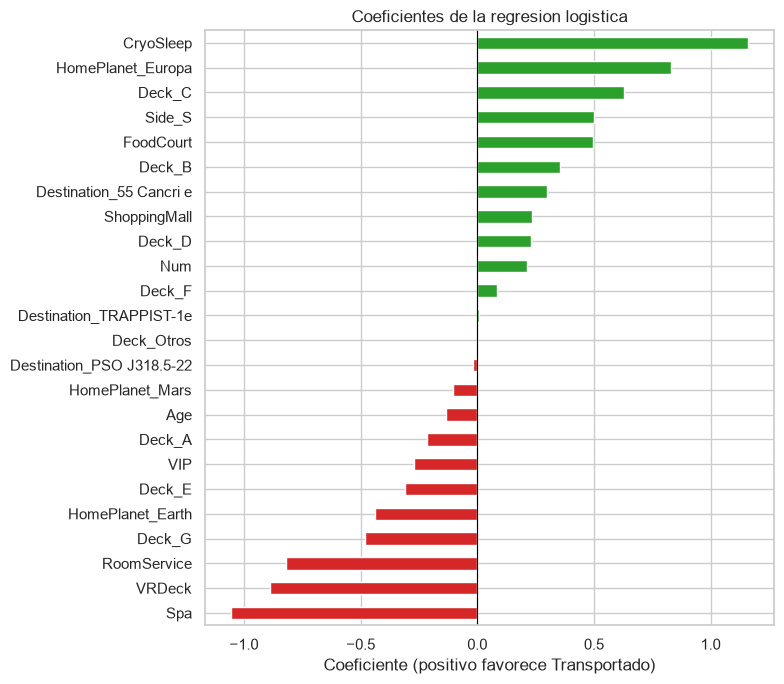

In [51]:
# ---- 11.1 Coeficientes: que variables pesan y en que direccion --------------
coef_logreg = pd.Series(logreg.coef_[0], index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colores = np.where(coef_logreg > 0, "tab:green", "tab:red")
coef_logreg.plot(kind="barh", ax=ax, color=colores)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Coeficientes de la regresion logistica")
ax.set_xlabel("Coeficiente (positivo favorece Transportado)")
plt.tight_layout()
plt.show()

La regresión logística alcanza 0.7809 de accuracy, casi 28 puntos por encima del baseline, con un ROC-AUC de 0.8591. Su accuracy en entrenamiento es 0.7780, prácticamente igual a la de prueba, lo que indica que no está sobreajustando: su límite es de sesgo y no de varianza.

Sus errores están casi equilibrados. La matriz de confusión muestra 199 falsos positivos contra 182 falsos negativos, y precision (0.7772) y recall (0.7922) quedan a menos de dos puntos de distancia. El modelo no prefiere ninguna de las dos clases, algo esperable en un dataset balanceado y sin ponderación explícita.

Los coeficientes confirman lo que anticipó la sección 8.2. `CryoSleep` es el coeficiente positivo más grande (1.16), es decir que viajar en criosueño aumenta fuertemente la probabilidad de haber sido transportado. Del otro lado aparecen `Spa` (-1.06), `VRDeck` (-0.89) y `RoomService` (-0.82): gastar en esos servicios la reduce. Llama la atención que `FoodCourt` tenga signo positivo (0.50) mientras los otros tres gastos son negativos, así que los cinco rubros no son intercambiables entre sí, y la decisión de la sección 3 de conservarlos por separado en lugar de sumarlos en un solo `TotalSpend` queda respaldada.

Dónde falla este modelo: asume que el efecto de cada variable es lineal y aditivo en la escala de log-odds. Si la relación real depende de combinaciones, por ejemplo que el gasto solo importe en ciertas cubiertas, la regresión logística no puede capturarla por construcción. Ese es justamente el terreno del siguiente modelo.

### 11.2 Random Forest

Hiperparámetros iniciales y la razón de cada valor:

- `n_estimators=300` equilibra estabilidad y tiempo. Con pocos árboles la predicción promediada varía mucho entre semillas; a partir de unos cientos la ganancia se aplana.
- `max_depth=None` deja crecer los árboles sin límite, porque en un bosque el control del sobreajuste viene del promediado de muchos árboles decorrelacionados y no de podar cada uno por separado.
- `max_features="sqrt"` hace que cada división considere unas 5 de las 24 variables, lo que fuerza a los árboles a ser distintos entre sí. Es el mecanismo que decorrela el ensamble.
- `min_samples_leaf=1` y `criterion="gini"` se dejan en su valor por defecto para que la sección 13 tenga margen de exploración.

A diferencia de la regresión logística, este modelo no necesitaba el escalado de la sección 7 ni la transformación `log1p` de la sección 6: los árboles parten por umbrales y son indiferentes a cualquier transformación monótona. Se entrena sobre los mismos datos para que la comparación sea justa.

In [52]:
# ---- 11.2 Random Forest ------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=1, max_features="sqrt",
    criterion="gini", random_state=RANDOM_STATE, n_jobs=-1,
)
rf.fit(X_train, y_train)

resultados.append(evaluar("Random Forest", rf, X_test, y_test))
print(f"accuracy en train: {rf.score(X_train, y_train):.4f}")
print(f"accuracy en test:  {rf.score(X_test, y_test):.4f}")
pd.DataFrame(resultados).set_index("modelo").round(4)

accuracy en train: 0.9996
accuracy en test:  0.8114


,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Baseline (clase mayoritaria),0.5037,0.5037,1.0000,0.6700,0.5000
Regresion logistica,0.7809,0.7772,0.7922,0.7846,0.8591
Random Forest,0.8114,0.8416,0.7705,0.8045,0.8946


In [53]:
# ---- 11.2 Matriz de confusion y reporte por clase ---------------------------
pred_rf = rf.predict(X_test)

cm_rf = pd.DataFrame(
    confusion_matrix(y_test, pred_rf),
    index=[f"real: {e}" for e in etiquetas],
    columns=[f"pred: {e}" for e in etiquetas],
)
print(cm_rf, "\n")
print(classification_report(y_test, pred_rf, target_names=etiquetas, digits=4))

                       pred: No transportado  pred: Transportado
real: No transportado                    736                 127
real: Transportado                       201                 675 

                 precision    recall  f1-score   support

No transportado     0.7855    0.8528    0.8178       863
   Transportado     0.8416    0.7705    0.8045       876

       accuracy                         0.8114      1739
      macro avg     0.8136    0.8117    0.8112      1739
   weighted avg     0.8138    0.8114    0.8111      1739



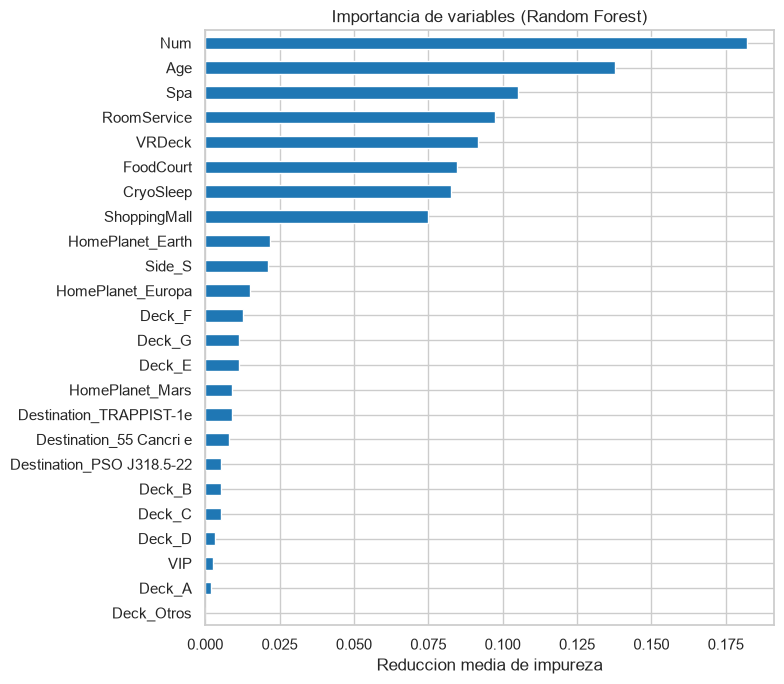

In [54]:
# ---- 11.2 Importancia de variables segun el bosque --------------------------
imp_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
imp_rf.plot(kind="barh", ax=ax, color="tab:blue")
ax.set_title("Importancia de variables (Random Forest)")
ax.set_xlabel("Reduccion media de impureza")
plt.tight_layout()
plt.show()

El Random Forest alcanza 0.8114 de accuracy y 0.8946 de ROC-AUC, por encima de la regresión logística en ambas. La brecha con su accuracy en entrenamiento es enorme: 0.9996 contra 0.8114. El bosque memoriza casi por completo el conjunto de entrenamiento y aun así generaliza mejor que el modelo lineal, que es el comportamiento típico de un ensamble con árboles sin podar. Esa brecha es una señal de que hay margen para regularizar, y es justo lo que explora la sección 13.

Sus errores no están equilibrados. La matriz de confusión muestra 201 falsos negativos contra 127 falsos positivos, y eso se refleja en una precision (0.8416) muy por encima del recall (0.7705). El modelo es conservador al declarar `Transportado`: cuando lo afirma acierta más que la logística, pero deja escapar más pasajeros que sí fueron transportados. En el contexto del problema, este modelo se equivoca sobre todo por omisión.

Las importancias revelan algo que conviene leer con cuidado. `Num` (0.182) y `Age` (0.138) encabezan la lista, mientras que `CryoSleep`, que era el coeficiente dominante de la regresión logística, queda en 0.083. Eso no significa que `CryoSleep` importe poco. La importancia por reducción de impureza premia a las variables continuas con muchos valores distintos, porque ofrecen muchos más puntos de corte posibles que una binaria: `Num` tiene 1,894 valores y `CryoSleep` solo dos. Es un sesgo conocido de esta métrica, y contrastar las dos vistas, coeficientes contra importancias, resulta más informativo que confiar en una sola.

## 12. Comparativa de modelos

In [55]:
# ---- 12.0 Tabla comparativa --------------------------------------------------
tabla_comparativa = pd.DataFrame(resultados).set_index("modelo").round(4)
tabla_comparativa

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Baseline (clase mayoritaria),0.5037,0.5037,1.0000,0.6700,0.5000
Regresion logistica,0.7809,0.7772,0.7922,0.7846,0.8591
Random Forest,0.8114,0.8416,0.7705,0.8045,0.8946


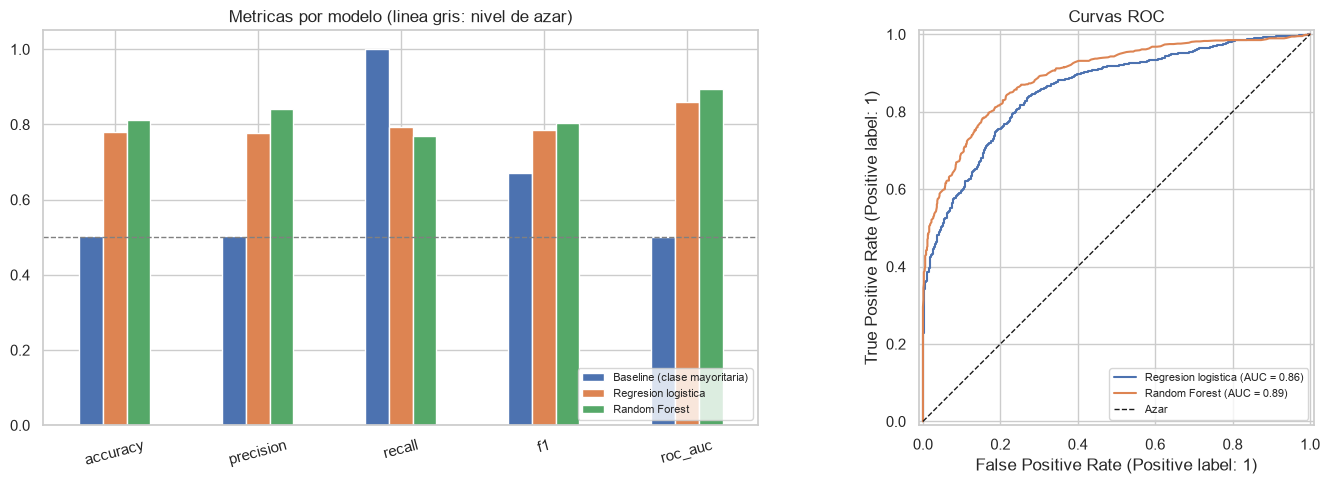

In [56]:
# ---- 12.0 Visualizacion comparativa -----------------------------------------
from sklearn.metrics import RocCurveDisplay

METRICAS = ["accuracy", "precision", "recall", "f1", "roc_auc"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

tabla_comparativa[METRICAS].T.plot(kind="bar", ax=ax1, rot=15)
ax1.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax1.set_title("Metricas por modelo (linea gris: nivel de azar)")
ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=8, loc="lower right")

for nombre, modelo in [("Regresion logistica", logreg), ("Random Forest", rf)]:
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=ax2, name=nombre)
ax2.plot([0, 1], [0, 1], "k--", linewidth=1, label="Azar")
ax2.set_title("Curvas ROC")
ax2.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

### 12.1 Modelo elegido: Random Forest

El Random Forest gana, pero la justificación no puede ser que tenga la accuracy más alta. Vale la pena recorrer las cinco métricas y ver qué aporta cada una.

En accuracy son 0.8114 contra 0.7809, unos 3 puntos de ventaja, y ambos modelos superan al baseline (0.5037) por un margen amplio, así que los dos aprendieron algo real del dataset. En ROC-AUC la ventaja se mantiene, 0.8946 contra 0.8591, y esta métrica es la más informativa de la tabla porque no depende del umbral: dice que el bosque ordena mejor a los pasajeros por probabilidad de haber sido transportados, no solo que acierta más al cortar en 0.5. En F1, 0.8045 contra 0.7846, el orden se confirma.

El único indicador a favor del modelo lineal es el recall, 0.7922 contra 0.7705, y conviene no esconderlo. Significa que el bosque deja escapar más positivos, como ya mostraba su matriz de confusión. La contraparte es que su precision es bastante superior, 0.8416 contra 0.7772, y como en este problema ningún tipo de error resulta más costoso que el otro, no hay razón para privilegiar el recall sobre la precisión. El F1, que resume ambos en un solo número, favorece al bosque.

Dos criterios secundarios completan la decisión. En interpretabilidad gana la logística, porque sus coeficientes se leen directamente como dirección y magnitud del efecto, mientras que el bosque solo ofrece importancias y con el sesgo hacia variables continuas ya comentado. En costo de entrenamiento también gana la logística, por bastante. Ninguna de las dos ventajas compensa una superioridad simultánea en accuracy, F1 y ROC-AUC, así que el modelo elegido es el Random Forest, con la observación de que su brecha entre entrenamiento (0.9996) y prueba (0.8114) sugiere sobreajuste y que vale la pena intentar regularizarlo.

## 13. Exploración individual de hiperparámetros

Cada integrante trabaja de forma independiente sobre el modelo elegido en la sección 12, el Random Forest, y modifica un hiperparámetro distinto respecto de la configuración base. Esa configuración base es la de la sección 11.2, y sus métricas sobre el conjunto de prueba son accuracy 0.8114, F1 0.8045 y ROC-AUC 0.8946, con accuracy en entrenamiento de 0.9996.

Las subsecciones siguientes documentan cada experimento. Todas usan la misma función y evalúan sobre el mismo `X_test`, para que los resultados sean comparables entre sí. Además de las cinco métricas se reporta la accuracy en entrenamiento, porque los cambios probados buscan precisamente reducir el sobreajuste detectado en la sección 11.2.

In [57]:
# ---- 13.0 Utilidad comun para los experimentos -----------------------------
PARAMS_BASE = dict(
    n_estimators=300, max_depth=None, min_samples_leaf=1, max_features="sqrt",
    criterion="gini", random_state=RANDOM_STATE, n_jobs=-1,
)

modelo_base = RandomForestClassifier(**PARAMS_BASE).fit(X_train, y_train)
metricas_base = evaluar("antes", modelo_base, X_test, y_test)
acc_train_base = modelo_base.score(X_train, y_train)


def experimento(cambio):
    """Reentrena el bosque con un hiperparametro cambiado y compara antes y despues."""
    modelo_nuevo = RandomForestClassifier(**{**PARAMS_BASE, **cambio}).fit(X_train, y_train)
    acc_train_nuevo = modelo_nuevo.score(X_train, y_train)

    tabla = pd.DataFrame(
        [metricas_base, evaluar("despues", modelo_nuevo, X_test, y_test)]
    ).set_index("modelo")
    tabla["accuracy_train"] = [acc_train_base, acc_train_nuevo]
    tabla.loc["diferencia"] = tabla.loc["despues"] - tabla.loc["antes"]
    return modelo_nuevo, tabla.round(4)

### 13.1 Juan Pablo Pérez Gutiérrez

Hiperparámetro elegido: `max_depth`, de `None` a `10`.

La razón para cambiarlo es la brecha que detectó la sección 11.2. El bosque alcanza 0.9996 de accuracy en entrenamiento contra 0.8114 en prueba, lo que indica que los árboles sin límite de profundidad están memorizando el conjunto de entrenamiento. Limitar la profundidad a 10 niveles impide que un árbol siga partiendo hasta aislar observaciones individuales.

Lo que esperaba: que la accuracy en entrenamiento bajara mucho y que la de prueba subiera un poco, o al menos se mantuviera, porque el modelo dejaría de ajustarse al ruido del entrenamiento.

In [58]:
modelo_jp, tabla_jp = experimento({"max_depth": 10})
tabla_jp

,accuracy,precision,recall,f1,roc_auc,accuracy_train
modelo,,,,,,
antes,0.8114,0.8416,0.7705,0.8045,0.8946,0.9996
despues,0.7936,0.8038,0.7808,0.7921,0.8984,0.8661
diferencia,-0.0178,-0.0379,0.0103,-0.0124,0.0038,-0.1334


El resultado fue parcialmente contrario a lo esperado. La accuracy en entrenamiento cayó de 0.9996 a 0.8661, así que la restricción sí cortó la memorización. Pero la accuracy en prueba también bajó, de 0.8114 a 0.7936, y el F1 pasó de 0.8045 a 0.7921.

El detalle interesante está en el ROC-AUC, que subió de 0.8946 a 0.8984. El modelo podado ordena a los pasajeros por probabilidad ligeramente mejor que el original, aunque acierte menos al cortar en el umbral de 0.5. Esto sugiere que la profundidad 10 es demasiado restrictiva para la decisión dura, pero produce probabilidades algo mejor calibradas al promediar árboles menos extremos.

La lectura general es que en un Random Forest el sobreajuste medido como brecha entre entrenamiento y prueba no se traduce automáticamente en mala generalización. El promediado de 300 árboles ya cancela buena parte de la varianza individual, así que podar además cuesta sesgo sin devolver desempeño. Un valor intermedio, entre 10 y sin límite, probablemente funcionaría mejor que cualquiera de los dos extremos.

### 13.2 Yael Michel García López

Hiperparámetro elegido: `min_samples_leaf`, de `1` a `5`.

Con el valor por defecto de 1 un árbol puede seguir partiendo hasta que una hoja contenga una sola observación, y una hoja así describe a un pasajero concreto más que a un patrón. Exigir al menos 5 observaciones por hoja es una forma de regularizar más suave que limitar la profundidad, porque no corta el árbol a una altura fija sino que solo impide las divisiones que ya no representan a un grupo.

Lo que esperaba: menos sobreajuste que el modelo base y mejores métricas de prueba que la poda por profundidad de la sección 13.1, precisamente por tratarse de una restricción menos rígida.

In [59]:
modelo_yael, tabla_yael = experimento({"min_samples_leaf": 5})
tabla_yael

,accuracy,precision,recall,f1,roc_auc,accuracy_train
modelo,,,,,,
antes,0.8114,0.8416,0.7705,0.8045,0.8946,0.9996
despues,0.8079,0.8203,0.7922,0.8060,0.9004,0.8781
diferencia,-0.0035,-0.0213,0.0217,0.0015,0.0058,-0.1215


La hipótesis se sostuvo en lo esencial. La accuracy en entrenamiento bajó de 0.9996 a 0.8781, así que la restricción sí controló la memorización, y a diferencia de la poda por profundidad el costo en prueba fue mínimo: la accuracy pasó de 0.8114 a 0.8079, apenas 0.35 puntos.

A cambio, dos métricas mejoraron. El F1 subió de 0.8045 a 0.8060 y el ROC-AUC de 0.8946 a 0.9004, que es el mejor valor de toda la sección 13. El recall pasó de 0.7705 a 0.7922, es decir que el modelo dejó de ser tan conservador y recuperó buena parte de los falsos negativos que la sección 11.2 le señalaba.

Comparado con la sección 13.1, este resultado sugiere que la forma de regularizar importa más que la cantidad. Ambos cambios redujeron el sobreajuste a un nivel parecido, 0.8781 contra 0.8661 en entrenamiento, pero `min_samples_leaf` lo hizo sin sacrificar capacidad de discriminación. Si hubiera que adoptar una sola modificación sobre el modelo base, sería esta.

### 13.3 Alberto Gallegos Hernandez

Hiperparámetro elegido: 

## 14. Verificación y cierre

### 14.1 Tabla resumen final

In [60]:
# ---- 14.1 Todas las configuraciones entrenadas en una sola tabla ------------
configuraciones = [
    ("Baseline (clase mayoritaria)", "strategy='most_frequent'", baseline, "Descartado"),
    ("Regresion logistica", "C=1.0, penalty='l2', max_iter=1000", logreg, "Descartado"),
    ("Random Forest (base)", "n_estimators=300, max_features='sqrt', max_depth=None", rf, "Elegido"),
    ("RF 13.1 Juan Pablo Perez", "base + max_depth=10", modelo_jp, "Descartado"),
    ("RF 13.2 Yael Garcia", "base + min_samples_leaf=5", modelo_yael, "Descartado"),
]

filas = []
for nombre, hiperparametros, modelo, decision in configuraciones:
    m = evaluar(nombre, modelo, X_test, y_test)
    filas.append({
        "Modelo": nombre,
        "Hiperparametros": hiperparametros,
        "Accuracy": round(m["accuracy"], 4),
        "F1": round(m["f1"], 4),
        "ROC-AUC": round(m["roc_auc"], 4),
        "Decision": decision,
    })

tabla_final = pd.DataFrame(filas)
with pd.option_context("display.max_colwidth", 60, "display.width", 200):
    print(tabla_final.to_string(index=False))

                      Modelo                                       Hiperparametros  Accuracy     F1  ROC-AUC   Decision
Baseline (clase mayoritaria)                              strategy='most_frequent'    0.5037 0.6700   0.5000 Descartado
         Regresion logistica                    C=1.0, penalty='l2', max_iter=1000    0.7809 0.7846   0.8591 Descartado
        Random Forest (base) n_estimators=300, max_features='sqrt', max_depth=None    0.8114 0.8045   0.8946    Elegido
    RF 13.1 Juan Pablo Perez                                   base + max_depth=10    0.7936 0.7921   0.8984 Descartado
         RF 13.2 Yael Garcia                             base + min_samples_leaf=5    0.8079 0.8060   0.9004 Descartado


In [61]:
# ---- 14.2 Archivo de envio para Kaggle --------------------------------------
# Se reentrena el modelo elegido con las 8693 filas etiquetadas, no solo con el 80%
modelo_final = RandomForestClassifier(**PARAMS_BASE).fit(X, y)
pred_kaggle = modelo_final.predict(df_test_kaggle).astype(bool)

submission = pd.DataFrame({
    "PassengerId": ids_kaggle["PassengerId"],
    "Transported": pred_kaggle,
})
submission.to_csv(PROCESSED_DIR / "submission.csv", index=False)

muestra = pd.read_csv(DATA_DIR / "sample_submission.csv")
print("submission:", submission.shape, "| formato esperado por Kaggle:", muestra.shape)
print("columnas coinciden:", list(submission.columns) == list(muestra.columns))
submission.head()

submission: (4277, 2) | formato esperado por Kaggle: (4277, 2)
columnas coinciden: True


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [62]:
# ---- 14.3 Verificacion de cierre --------------------------------------------
assert df_train.isna().sum().sum() == 0, "quedan nulos en el dataset procesado"
assert X_train.shape[0] + X_test.shape[0] == df_train.shape[0], "la particion no cuadra"
assert submission.shape == (df_test_kaggle.shape[0], 2), "el envio no tiene el tamanio esperado"

hiperparametros_individuales = ["max_depth", "min_samples_leaf"]
assert len(set(hiperparametros_individuales)) == len(hiperparametros_individuales), \
    "hay integrantes repitiendo hiperparametro"

print("OK: particion, dataset procesado y archivo de envio verificados")
print(f"OK: {len(hiperparametros_individuales)} hiperparametros distintos en la seccion 13")
print(f"OK: modelo elegido con accuracy {rf.score(X_test, y_test):.4f} sobre el conjunto de prueba")

OK: particion, dataset procesado y archivo de envio verificados
OK: 2 hiperparametros distintos en la seccion 13


OK: modelo elegido con accuracy 0.8114 sobre el conjunto de prueba


### 14.4 Conclusión del equipo

**Qué aprendimos del comportamiento de los modelos sobre este dataset.**

Lo primero es que las dos familias llegan a un techo parecido, alrededor de 0.78 a 0.81 de accuracy, muy por encima del baseline de 0.5037 pero lejos de un desempeño perfecto. Eso sugiere que el límite no está en el modelo sino en la información disponible: las 24 variables que produjo el preprocesamiento explican buena parte del fenómeno, pero no todo.

Las dos familias fallan de manera distinta, y ese contraste fue más informativo que la diferencia de accuracy. La regresión logística reparte sus errores casi por igual entre falsos positivos y falsos negativos, mientras que el Random Forest es claramente conservador: acierta más cuando afirma que un pasajero fue transportado, pero deja escapar más casos positivos. Ninguna de las dos conductas es preferible en abstracto, depende de qué error resulte más caro, y en este problema ninguno lo es.

`CryoSleep` volvió a aparecer como la variable con más señal, tal como anticipaba la sección 8.2, aunque solo la regresión logística lo muestra de forma directa. En el Random Forest quedó en séptimo lugar de importancia, por debajo de `Num` y `Age`, y entender que eso es un sesgo conocido de la importancia por impureza y no un hallazgo sobre los datos fue uno de los aprendizajes más útiles del ejercicio.

De la sección 13 sacamos que la forma de regularizar importa más que la intensidad. Los dos cambios probados, `max_depth=10` y `min_samples_leaf=5`, redujeron el sobreajuste a un nivel casi idéntico, 0.8661 y 0.8781 de accuracy en entrenamiento frente a 0.9996 del modelo base, pero con consecuencias muy distintas. Limitar la profundidad costó 1.8 puntos de accuracy en prueba, mientras que exigir un mínimo de observaciones por hoja costó apenas 0.35 y a cambio mejoró el F1 y el ROC-AUC. También aprendimos que un sobreajuste aparente muy grande no siempre se corrige subiendo la regularización, porque ninguno de los dos cambios mejoró la accuracy de prueba.

**Qué haríamos diferente en la siguiente iteración.**

Partiríamos los datos antes de preprocesar, no después. Como se explicó en la sección 9.3, las medianas, modas y parámetros de escalado se aprendieron sobre todo `train.csv`, incluidas las filas que después quedaron como conjunto de prueba, lo que deja la evaluación con un sesgo optimista. Lo correcto es hacer el split primero y encapsular todo el preprocesamiento en un `Pipeline` de scikit-learn.

Añadiríamos las variables que el propio notebook identificó y nunca construyó. La sección 6 concluyó que el sesgo residual de los gastos es exceso de ceros y que la vía correcta sería una indicadora `HaGastado`; nunca se creó. Sobre todo añadiríamos el tamaño del grupo de viaje: `Group` se usó solo como llave temporal de imputación y se descartó, pese a que la tasa de transportados va de 45.2% entre quienes viajan solos a 64.1% en grupos de cuatro personas. Es señal clara que se quedó fuera del modelo. En cambio no agregaríamos un `TotalSpend`: la sección 3 ya argumentó con evidencia que los cinco rubros se relacionan de forma distinta con el target y que sumarlos promediaría esa diferencia.

Cambiaríamos también la forma de buscar hiperparámetros. La sección 13 modifica uno a la vez sobre un holdout fijo, lo que sirve para entender el efecto de cada uno por separado pero no encuentra buenas combinaciones ni protege contra ajustar las decisiones a ese conjunto en particular. Un `GridSearchCV` o `RandomizedSearchCV` con validación cruzada sobre el conjunto de entrenamiento resolvería ambos problemas. Y como primer candidato concreto adoptaríamos `min_samples_leaf=5`, que en la sección 13.2 obtuvo el mejor ROC-AUC de la exploración (0.9004) reduciendo el sobreajuste casi sin costo en accuracy.

Por último, probaríamos una familia más, un modelo de boosting como `HistGradientBoostingClassifier`, que en problemas tabulares de este tipo suele quedar por encima tanto de un modelo lineal como de un bosque.

---

## Nota de uso de IA

**Herramienta utilizada:** Claude (Anthropic), a través de Claude Code.

**Organización y formato del notebook.** El archivo se encontraba desordenado y con celdas incompletas. Se apoyó en la IA para estructurarlo en las ocho secciones que pide la actividad, mantener el patrón consistente de *celda de código con la evidencia seguida de celda de interpretación con el razonamiento*, y homogeneizar comentarios y encabezados.

**Correcciones de sintaxis y compatibilidad.**

- Se corrigió la ruta de carga: `DATA_DIR` ahora resuelve `data/spaceship-titanic/` tanto si el notebook se ejecuta desde su propia carpeta como desde la raíz del repositorio.
- Se corrigió un `TypeError` en `select_dtypes(include=["object", "str"])`, sintaxis válida en pandas 3 pero no en pandas 2.
- Se añadió un casteo explícito a `bool` en `CryoSleep` y `VIP`: sin él, el `dtype` resultante dependía de la versión de pandas instalada y el notebook producía resultados distintos en las máquinas de cada integrante.
- Se repuso la celda de carga de los CSV, eliminada accidentalmente durante un merge de Git.

**Guía metodológica.** Antes de implementar la sección 4 se usó la IA para explicar, sobre un conjunto de datos de ejemplo ajeno a la actividad, la distinción entre *faltante informativo* y *faltante real* y las funciones disponibles para tratarlos, con el fin de comprender el criterio antes de aplicarlo al dataset propio.

**Redacción asistida de las secciones 4 a 7.** El código y las celdas de interpretación de manejo de faltantes, codificación, transformación y escalado se elaboraron con asistencia de la IA, partiendo de la evidencia numérica producida por el EDA del equipo (secciones 2 y 3). Las decisiones se sustentaron en mediciones sobre el dataset y no en valores por defecto: por ejemplo, la imputación por grupo de viaje se justificó verificando que 0 de 6217 grupos presentan más de un `HomePlanet`; el descarte de la codificación ordinal para `Deck` se sustentó en la no monotonía observada en el crosstab de la sección 2.4; y la elección de `RobustScaler` sobre `StandardScaler` se resolvió comparando explícitamente a dónde envía cada uno el valor 0 de las columnas de gasto.

**Verificación.** El notebook completo se ejecutó de principio a fin bajo pandas 2.3.3 y pandas 3.0.5, confirmando que corre sin errores y entrega resultados idénticos en ambas versiones.

**Segundo avance (secciones 9 a 14).** Se usó la misma herramienta para estructurar las seis etapas de modelado que pide la actividad y para redactar el código de entrenamiento, comparación y exploración de hiperparámetros. Las interpretaciones se escribieron a partir de los resultados que arrojó el notebook y no de valores esperados: la elección del Random Forest se sostiene comparando las cinco métricas y reconociendo que el recall favorece a la regresión logística, y la sección 13.1 documenta un resultado que contradijo la hipótesis inicial. En el proceso se detectaron dos bloqueos del avance anterior: que el pipeline no exportaba su resultado y que `test.csv` no incluye la columna objetivo, lo que obligó a evaluar sobre una partición de `train.csv`.

**Trabajo elaborado directamente por el equipo:** _(completar: indicar aquí las secciones 1, 2, 3 y 8 y las interpretaciones del EDA que cada integrante desarrolló, y si se utilizó alguna otra herramienta de IA en ellas)_

**Responsabilidad.** El equipo revisó, ejecutó y validó la totalidad del contenido generado con asistencia de IA, y asume la responsabilidad sobre las decisiones e interpretaciones presentadas en este notebook.